# Анализ публичных компаний фондовых бирж АСЕАН
## В контексте торгового сотрудничества России со странами АСЕАН

**Источник данных:** 5 фондовых бирж (IDX, Bursa Malaysia, SET, HOSE/HNX/UPCOM, SGX)  
**Выборка:** 5 245 публичных компаний  
**Показатели:** рыночная капитализация, цена акций, объём торгов, секторальная принадлежность (ISIC Rev.4)  
**Дополнительно:** выручка, прибыль, FCF (Индонезия); P/E, дивидендная доходность (Малайзия)

In [1]:
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import defaultdict
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

BASE_DIR = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
OUT_DIR = os.path.join(BASE_DIR, 'Company_analysis', 'charts')
os.makedirs(OUT_DIR, exist_ok=True)

# --- Валютные курсы (к USD) ---
FX = {'Indonesia': 1/16000, 'Singapore': 0.74, 'Thailand': 1/35,
      'Malaysia': 1/4.5, 'Vietnam': 1/25000}

COUNTRY_RU = {'Indonesia': 'Индонезия', 'Malaysia': 'Малайзия',
              'Thailand': 'Таиланд', 'Vietnam': 'Вьетнам', 'Singapore': 'Сингапур'}
EXCHANGE = {'Indonesia': 'IDX', 'Malaysia': 'Bursa Malaysia',
            'Thailand': 'SET', 'Vietnam': 'HOSE/HNX/UPCOM', 'Singapore': 'SGX'}
COUNTRIES = ['Indonesia', 'Malaysia', 'Thailand', 'Vietnam', 'Singapore']

ISIC_NAMES = {
    'A': 'Сельское хозяйство',
    'B': 'Добыча полезных ископаемых',
    'C': 'Обрабатывающая промышленность',
    'D': 'Электро-/газоснабжение',
    'E': 'Водоснабжение и утилизация',
    'F': 'Строительство',
    'G': 'Торговля опт./розн.',
    'H': 'Транспорт и хранение',
    'I': 'Гостиницы и рестораны',
    'J': 'Информация и связь',
    'K': 'Финансы и страхование',
    'L': 'Операции с недвижимостью',
    'M': 'Проф./науч./техн. деятельность',
    'N': 'Адм. и вспомогат. деятельность',
    'O': 'Государственное управление',
    'P': 'Образование',
    'Q': 'Здравоохранение',
    'R': 'Искусство и развлечения',
    'S': 'Прочие услуги',
}

print(f'Рабочая директория: {BASE_DIR}')
print(f'Графики → {OUT_DIR}')

Рабочая директория: C:\Users\Данила\Desktop\parsing_companies
Графики → C:\Users\Данила\Desktop\parsing_companies\Company_analysis\charts


---
## Блок 1. Загрузка и очистка данных

In [2]:
# --- Загрузка консолидированного датасета ---
with open(os.path.join(BASE_DIR, 'asean_consolidated.json'), 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)
df = df[df['Country'].isin(COUNTRIES)].copy()

# Приведение типов
for col in ['Market_Cap', 'Stock_Price', 'Volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Капитализация в USD (млрд)
df['MCap_USD_B'] = df.apply(lambda r: r['Market_Cap'] * FX.get(r['Country'], 1) / 1e9
                            if r['Market_Cap'] > 0 else 0, axis=1)

# Лог-капитализация (для кластеризации)
df['log_MCap'] = np.where(df['Market_Cap'] > 0, np.log(df['Market_Cap']), np.nan)

# Биржа (русское название)
df['Exchange_Name'] = df['Country'].map(EXCHANGE)
df['Country_RU'] = df['Country'].map(COUNTRY_RU)

# Флаги наличия данных
df['has_mcap'] = (df['Market_Cap'] > 0).astype(int)
df['has_price'] = (df['Stock_Price'] > 0).astype(int)
df['has_volume'] = (df['Volume'] > 0).astype(int)
df['has_isic'] = df['ISIC_Section'].notna() & (df['ISIC_Section'] != '')

print(f'Загружено компаний: {len(df)}')
print(f'Стран: {df["Country"].nunique()}')
print(f'С капитализацией > 0: {df["has_mcap"].sum()}')
print(f'С ISIC-классификацией: {df["has_isic"].sum()}')
print()
df.groupby('Country')[['has_mcap', 'has_price', 'has_volume', 'has_isic']].sum()

Загружено компаний: 5245
Стран: 5
С капитализацией > 0: 4973
С ISIC-классификацией: 5151



,has_mcap,has_price,has_volume,has_isic
Country,,,,
Indonesia,948,952,919,955
Malaysia,1116,1116,914,1114
Singapore,448,449,449,670
Thailand,918,921,916,871
Vietnam,1543,1494,904,1541


In [3]:
# --- Загрузка дополнительных финансовых данных ---

# 1. Индонезия: Revenue, Net Income, FCF (старый датасет, 902 компании)
with open(os.path.join(BASE_DIR, 'Indonesia', 'old', 'merged_companies_data.json'), 'r', encoding='utf-8') as f:
    idx_old = json.load(f)

def parse_idr(val):
    """Конвертация строк вида '53.28T', '2,501.30B', '-10.88%' в числа."""
    if not val or val in ('-', '', 'None'):
        return np.nan
    s = str(val).strip().replace(',', '').replace('%', '')
    s = s.replace('T', 'e12').replace('B', 'e9').replace('M', 'e6').replace('K', 'e3')
    try:
        return float(s)
    except ValueError:
        return np.nan

idx_fin = pd.DataFrame(idx_old)[['Ticker', 'Revenue', 'Revenue_Growth', 'Net_Income', 'Free_Cash_Flow']].copy()
for col in ['Revenue', 'Revenue_Growth', 'Net_Income', 'Free_Cash_Flow']:
    idx_fin[col] = idx_fin[col].apply(parse_idr)

# Мержим по тикеру
df = df.merge(idx_fin, on='Ticker', how='left')

# Производные показатели (только для Индонезии)
df['Profit_Margin'] = np.where(
    (df['Revenue'] > 0) & (df['Country'] == 'Indonesia'),
    df['Net_Income'] / df['Revenue'] * 100, np.nan)
df['FCF_Margin'] = np.where(
    (df['Revenue'] > 0) & (df['Country'] == 'Indonesia'),
    df['Free_Cash_Flow'] / df['Revenue'] * 100, np.nan)
df['Is_Profitable'] = np.where(df['Net_Income'].notna(), (df['Net_Income'] > 0).astype(int), np.nan)

# 2. Малайзия: PE_Ratio, Dividend_Yield
with open(os.path.join(BASE_DIR, 'Malaysia', 'bursa_companies.json'), 'r', encoding='utf-8') as f:
    my_raw = json.load(f)
my_fin = pd.DataFrame(my_raw)[['Ticker', 'PE_Ratio', 'Dividend_Yield']].copy()
my_fin['PE_Ratio'] = pd.to_numeric(my_fin['PE_Ratio'], errors='coerce')
my_fin['Dividend_Yield'] = pd.to_numeric(my_fin['Dividend_Yield'], errors='coerce')
# Rename to avoid collision
my_fin = my_fin.rename(columns={'Ticker': 'Ticker_MY'})

# Merge by ticker for Malaysia only
my_mask = df['Country'] == 'Malaysia'
df.loc[my_mask, 'PE_Ratio'] = df.loc[my_mask, 'Ticker'].map(
    my_fin.set_index('Ticker_MY')['PE_Ratio'])
df.loc[my_mask, 'Dividend_Yield'] = df.loc[my_mask, 'Ticker'].map(
    my_fin.set_index('Ticker_MY')['Dividend_Yield'])

n_rev = df['Revenue'].notna().sum()
n_pe = df['PE_Ratio'].notna().sum()
n_div = df['Dividend_Yield'].notna().sum()
print(f'Доп. данные подгружены:')
print(f'  IDX Revenue/Income/FCF: {n_rev} компаний')
print(f'  Bursa PE_Ratio: {n_pe} компаний')
print(f'  Bursa Dividend_Yield: {n_div} компаний')

Доп. данные подгружены:
  IDX Revenue/Income/FCF: 920 компаний
  Bursa PE_Ratio: 1112 компаний
  Bursa Dividend_Yield: 1116 компаний


---
## Блок 2. Обзор фондовых рынков АСЕАН

In [4]:
# --- Сводная таблица по биржам ---
summary = df.groupby('Country').agg(
    Компаний=('Ticker', 'count'),
    С_ценой=('has_price', 'sum'),
    С_капитализацией=('has_mcap', 'sum'),
    Секторов_ISIC=('ISIC_Section', lambda x: x.dropna().nunique()),
    Капитализация_USD_B=('MCap_USD_B', 'sum'),
    Медианная_MCap_USD_M=('MCap_USD_B', lambda x: x[x > 0].median() * 1000),
).reindex(COUNTRIES)

summary['Биржа'] = summary.index.map(EXCHANGE)
summary = summary[['Биржа', 'Компаний', 'С_ценой', 'С_капитализацией',
                    'Секторов_ISIC', 'Капитализация_USD_B', 'Медианная_MCap_USD_M']]
summary.columns = ['Биржа', 'Компаний', 'С ценой', 'С капитализацией',
                    'Секторов ISIC', 'Капитализация ($ млрд)', 'Медиана MCap ($ млн)']
summary.loc['ИТОГО'] = ['', summary['Компаний'].sum(), summary['С ценой'].sum(),
                         summary['С капитализацией'].sum(), '',
                         summary['Капитализация ($ млрд)'].sum(),
                         df[df['MCap_USD_B'] > 0]['MCap_USD_B'].median() * 1000]
summary['Капитализация ($ млрд)'] = summary['Капитализация ($ млрд)'].apply(
    lambda x: f'{x:,.1f}' if isinstance(x, (int, float)) else x)
summary['Медиана MCap ($ млн)'] = summary['Медиана MCap ($ млн)'].apply(
    lambda x: f'{x:,.1f}' if isinstance(x, (int, float)) else x)

print('Сводная характеристика фондовых бирж АСЕАН:')
display(summary)

Сводная характеристика фондовых бирж АСЕАН:


,Биржа,Компаний,С ценой,С капитализацией,Секторов ISIC,Капитализация ($ млрд),Медиана MCap ($ млн)
Country,,,,,,,
Indonesia,IDX,955,952,948,16,773.1,65.6
Malaysia,Bursa Malaysia,1116,1116,1116,13,468.4,38.4
Thailand,SET,932,921,918,14,519.1,42.0
Vietnam,HOSE/HNX/UPCOM,1547,1494,1543,14,221.5,8.1
Singapore,SGX,695,449,448,15,669.7,49.2
ИТОГО,,5245,4932,4973,,"2,651.8",28.8


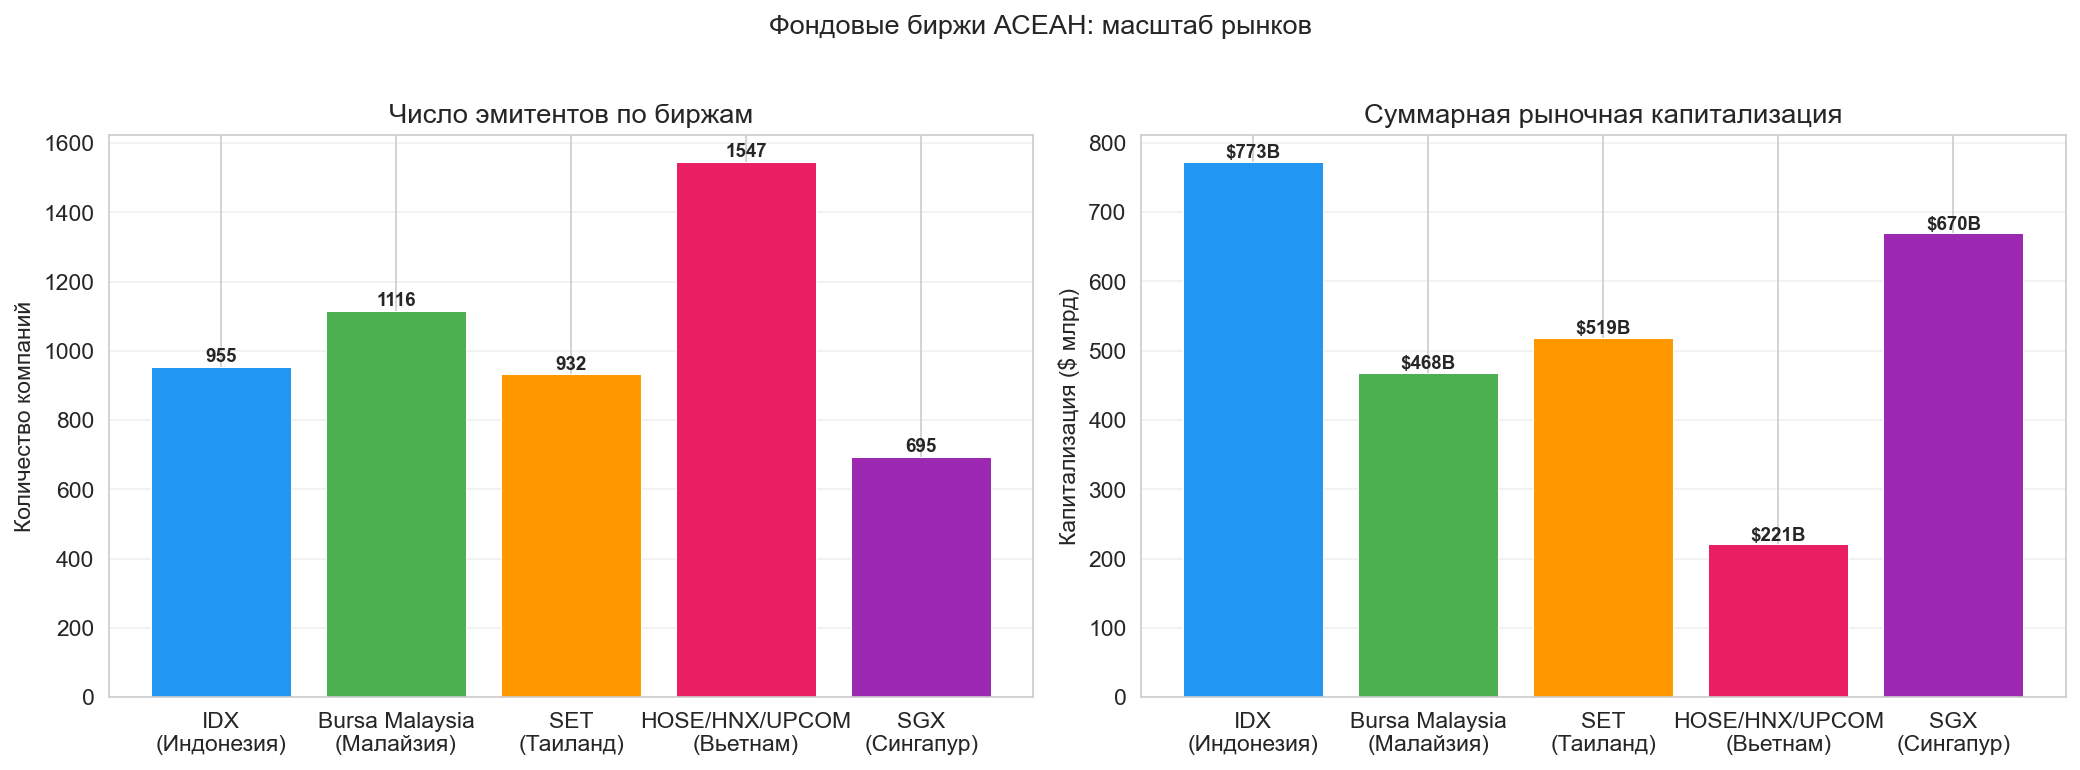

In [5]:
# --- Визуализация: кол-во компаний и капитализация по биржам ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors_country = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

# Количество компаний
counts = df.groupby('Country').size().reindex(COUNTRIES)
labels = [f'{EXCHANGE[c]}\n({COUNTRY_RU[c]})' for c in COUNTRIES]
bars1 = ax1.bar(labels, counts.values, color=colors_country, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars1, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
             str(int(val)), ha='center', fontsize=9, fontweight='bold')
ax1.set_ylabel('Количество компаний')
ax1.set_title('Число эмитентов по биржам')
ax1.grid(axis='y', alpha=0.3)

# Капитализация
mcaps = df.groupby('Country')['MCap_USD_B'].sum().reindex(COUNTRIES)
bars2 = ax2.bar(labels, mcaps.values, color=colors_country, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars2, mcaps.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'${val:,.0f}B', ha='center', fontsize=9, fontweight='bold')
ax2.set_ylabel('Капитализация ($ млрд)')
ax2.set_title('Суммарная рыночная капитализация')
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Фондовые биржи АСЕАН: масштаб рынков', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '01_exchanges_overview.png'), dpi=150, bbox_inches='tight')
plt.show()

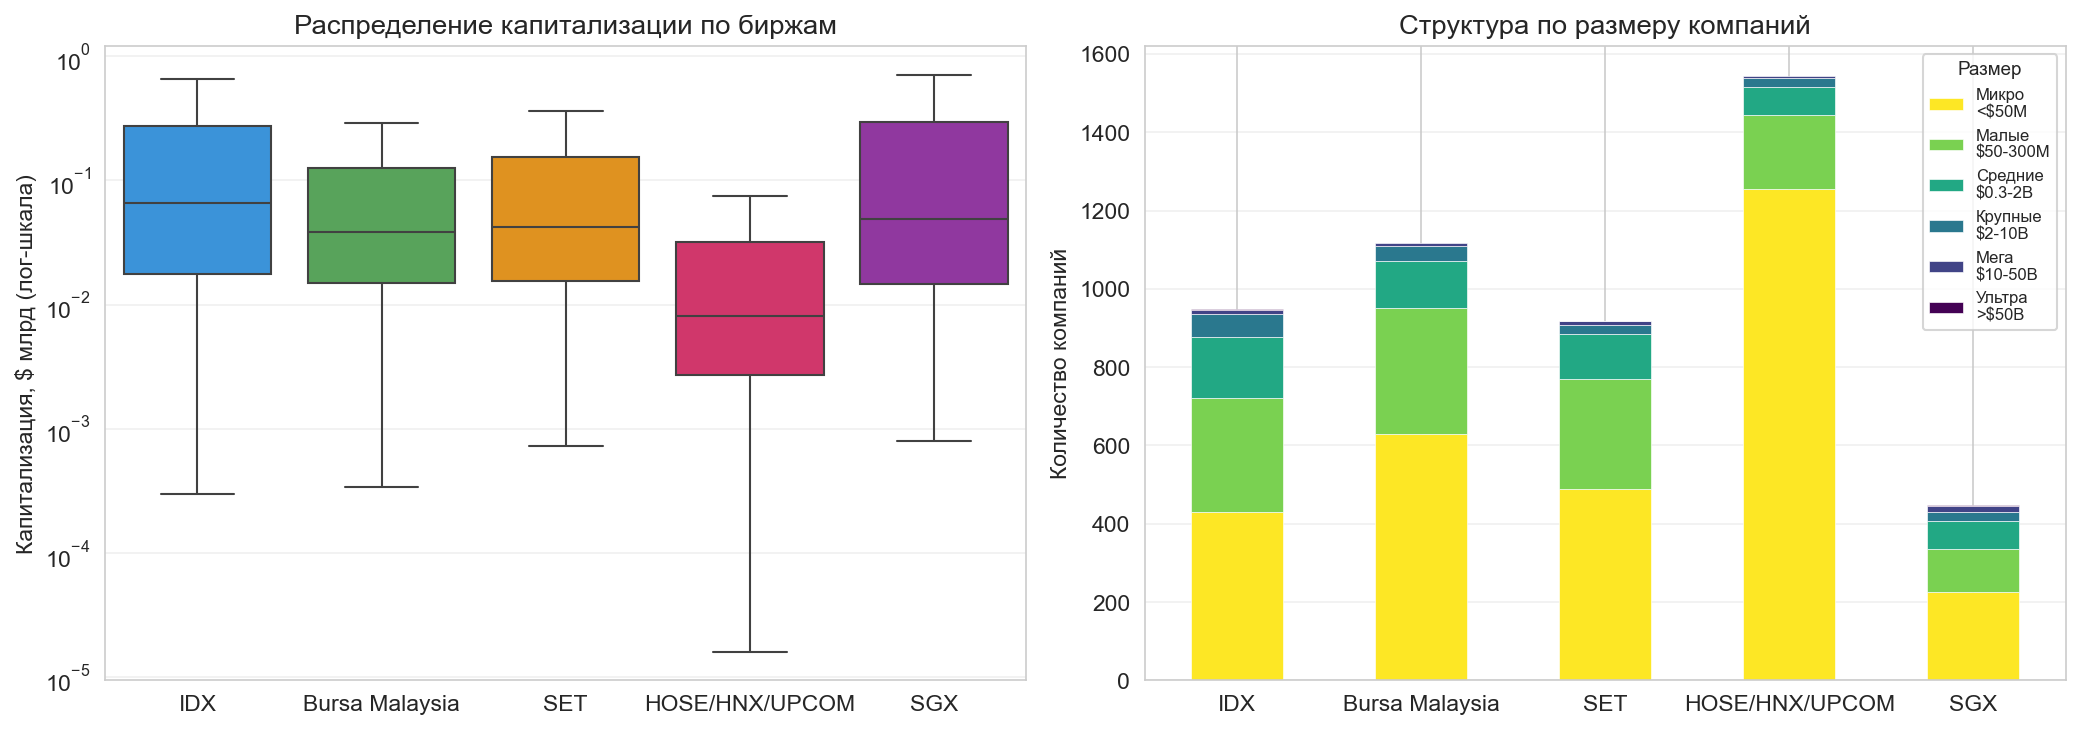

In [6]:
# --- Распределение капитализации (лог-шкала, boxplot по биржам) ---
df_active = df[df['MCap_USD_B'] > 0].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot капитализации
order = [EXCHANGE[c] for c in COUNTRIES]
sns.boxplot(data=df_active, x='Exchange_Name', y='MCap_USD_B', order=order,
            palette=colors_country, ax=ax1, showfliers=False)
ax1.set_yscale('log')
ax1.set_ylabel('Капитализация, $ млрд (лог-шкала)')
ax1.set_xlabel('')
ax1.set_title('Распределение капитализации по биржам')
ax1.grid(axis='y', alpha=0.3)

# Гистограмма: распределение по размеру компании
bins = [0, 0.05, 0.3, 2, 10, 50, 200]
labels_size = ['Микро\n<$50M', 'Малые\n$50-300M', 'Средние\n$0.3-2B',
               'Крупные\n$2-10B', 'Мега\n$10-50B', 'Ультра\n>$50B']
df_active['Size_Bucket'] = pd.cut(df_active['MCap_USD_B'], bins=bins, labels=labels_size)

size_by_country = df_active.groupby(['Country', 'Size_Bucket'], observed=True).size().unstack(fill_value=0)
size_by_country = size_by_country.reindex(COUNTRIES)
size_by_country.plot(kind='bar', stacked=True, ax=ax2, colormap='viridis_r', edgecolor='white', linewidth=0.3)
ax2.set_xticklabels([EXCHANGE[c] for c in COUNTRIES], rotation=0)
ax2.set_ylabel('Количество компаний')
ax2.set_xlabel('')
ax2.set_title('Структура по размеру компаний')
ax2.legend(title='Размер', fontsize=8, title_fontsize=9, loc='upper right')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '02_mcap_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Блок 3. Секторальная структура (ISIC Rev.4)

In [7]:
# --- Секторальная матрица: кол-во компаний (ISIC × страна) ---
df_isic = df[df['has_isic']].copy()
all_sections = sorted(df_isic['ISIC_Section'].unique())

cross_n = pd.crosstab(df_isic['ISIC_Section'], df_isic['Country'])[COUNTRIES]
cross_n['Итого'] = cross_n.sum(axis=1)
cross_n = cross_n.sort_values('Итого', ascending=False)

# Капитализация
cross_m = df_isic.groupby(['ISIC_Section', 'Country'])['MCap_USD_B'].sum().unstack(fill_value=0)
cross_m = cross_m.reindex(columns=COUNTRIES, fill_value=0)
cross_m['Итого'] = cross_m.sum(axis=1)
cross_m = cross_m.loc[cross_n.index]

print('Секторальная структура АСЕАН (число компаний):')
display(cross_n)

print('\nСекторальная структура АСЕАН (капитализация, $ млрд):')
display(cross_m.round(1))

Секторальная структура АСЕАН (число компаний):


Country,Indonesia,Malaysia,Thailand,Vietnam,Singapore,Итого
ISIC_Section,,,,,,
C,202,396,113,404,161,1276
F,51,153,73,335,95,707
L,92,119,214,119,68,612
K,95,42,82,89,107,415
J,84,105,99,61,51,400
A,72,79,87,65,7,310
D,18,29,63,107,32,249
S,11,84,5,94,55,249
H,47,35,35,113,9,239



Секторальная структура АСЕАН (капитализация, $ млрд):


Country,Indonesia,Malaysia,Thailand,Vietnam,Singapore,Итого
ISIC_Section,,,,,,
C,99.1,78.2,16.2,48.4,100.9,342.8
F,14.3,29.8,4.0,10.5,106.8,165.4
L,32.5,38.1,43.9,39.6,55.7,209.8
K,182.3,115.8,87.1,63.2,292.5,741.0
J,95.2,33.9,155.6,3.7,69.7,358.2
A,30.2,39.2,23.7,2.8,0.0,95.8
D,59.6,42.6,95.6,7.1,4.4,209.4
S,25.9,18.7,0.1,3.6,6.2,54.4
H,6.6,15.6,33.2,18.6,0.2,74.2


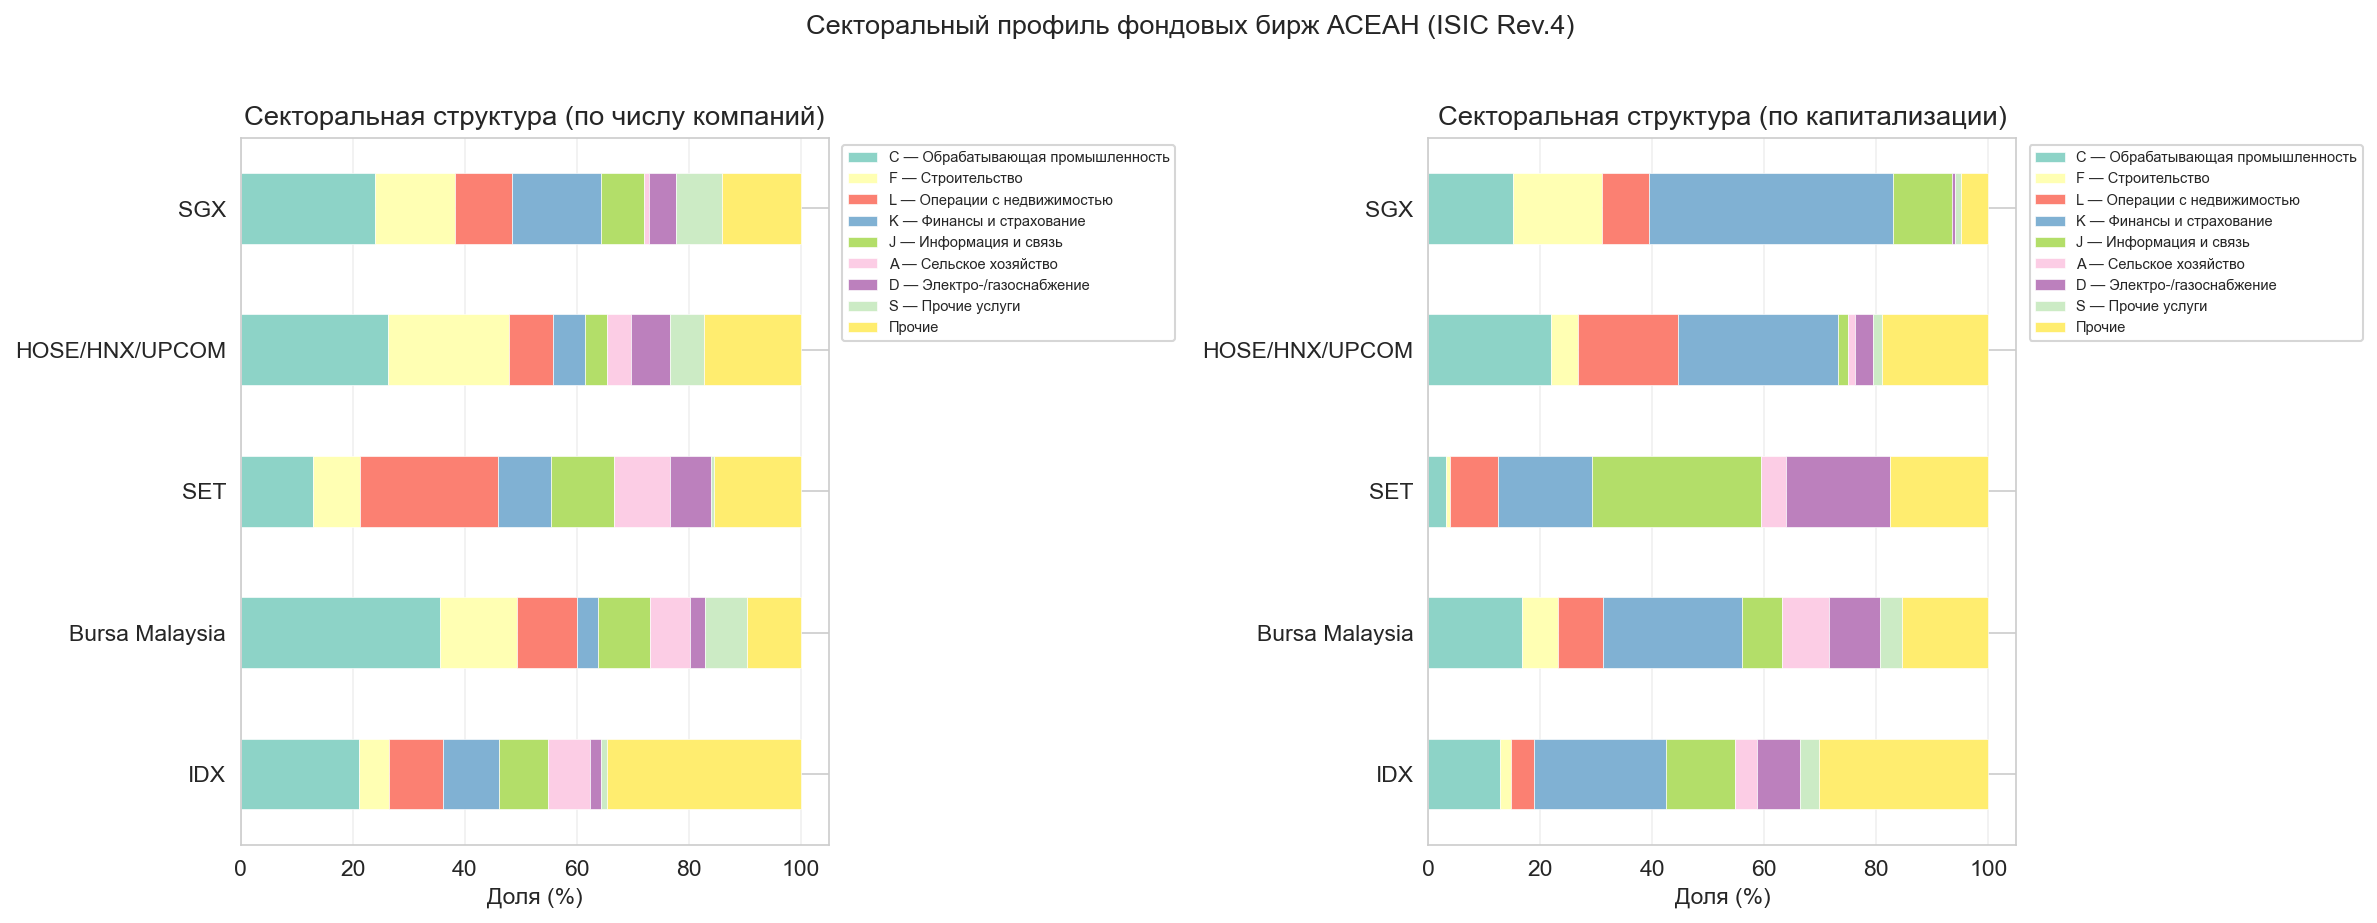

In [8]:
# --- Stacked bar: секторальная структура по странам ---
top_sections = cross_n.index[:8]  # 8 крупнейших секторов

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# По числу компаний (нормализованное)
sector_pct = pd.crosstab(df_isic['Country'], df_isic['ISIC_Section'], normalize='index') * 100
sector_pct = sector_pct.reindex(COUNTRIES)
plot_cols = [s for s in top_sections if s in sector_pct.columns]
sector_plot = sector_pct[plot_cols].copy()
sector_plot['Прочие'] = 100 - sector_plot.sum(axis=1)

cmap = plt.cm.Set3(np.linspace(0, 1, len(sector_plot.columns)))
legend_labels = [f'{s} — {ISIC_NAMES.get(s, s)}' for s in plot_cols] + ['Прочие']
sector_plot.plot(kind='barh', stacked=True, ax=ax1, color=cmap, edgecolor='white', linewidth=0.3)
ax1.set_yticklabels([EXCHANGE[c] for c in COUNTRIES])
ax1.set_xlabel('Доля (%)')
ax1.set_ylabel('')
ax1.set_title('Секторальная структура (по числу компаний)')
ax1.legend(legend_labels, fontsize=7, title_fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
ax1.grid(axis='x', alpha=0.3)

# По капитализации
mcap_pct = df_isic.groupby(['Country', 'ISIC_Section'])['MCap_USD_B'].sum().unstack(fill_value=0)
mcap_pct = mcap_pct.reindex(COUNTRIES).div(mcap_pct.reindex(COUNTRIES).sum(axis=1), axis=0) * 100
mcap_plot = mcap_pct[plot_cols].copy()
mcap_plot['Прочие'] = 100 - mcap_plot.sum(axis=1)

mcap_plot.plot(kind='barh', stacked=True, ax=ax2, color=cmap, edgecolor='white', linewidth=0.3)
ax2.set_yticklabels([EXCHANGE[c] for c in COUNTRIES])
ax2.set_xlabel('Доля (%)')
ax2.set_ylabel('')
ax2.set_title('Секторальная структура (по капитализации)')
ax2.legend(legend_labels, fontsize=7, title_fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('Секторальный профиль фондовых бирж АСЕАН (ISIC Rev.4)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '03_sector_structure.png'), dpi=150, bbox_inches='tight')
plt.show()

Индекс Херфиндаля — Хиршмана секторальной концентрации:


,Биржа,Компаний,Секторов,HHI,Концентрация,Лидер,Доля лидера
0,IDX,955,16,1100,Низкая,C (Обрабатывающая промышленн),21.2%
1,Bursa Malaysia,1114,13,1807,Умеренная,C (Обрабатывающая промышленн),35.5%
2,SET,871,14,1266,Низкая,L (Операции с недвижимостью),24.6%
3,HOSE/HNX/UPCOM,1541,14,1454,Низкая,C (Обрабатывающая промышленн),26.2%
4,SGX,670,15,1330,Низкая,C (Обрабатывающая промышленн),24.0%


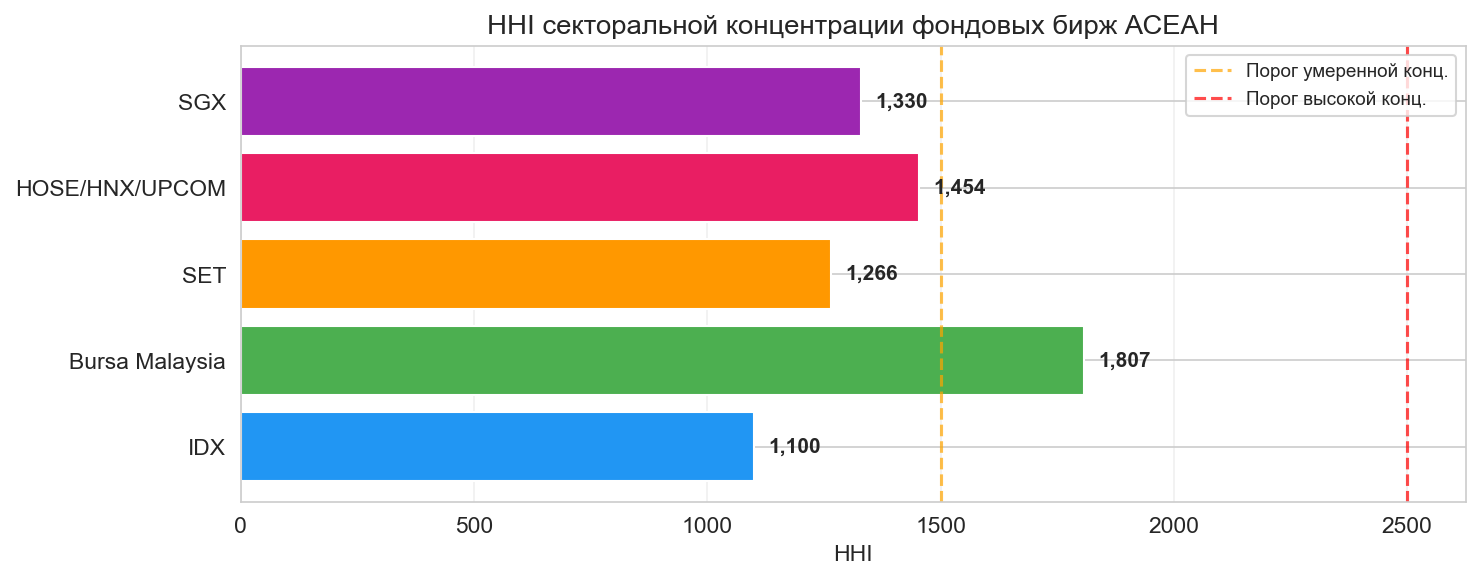

In [9]:
# --- HHI секторальной концентрации по биржам ---
hhi_data = []
for co in COUNTRIES:
    co_df = df_isic[df_isic['Country'] == co]
    total = len(co_df)
    sector_shares = co_df['ISIC_Section'].value_counts() / total * 100
    hhi = (sector_shares ** 2).sum()
    top1 = sector_shares.index[0]
    top1_pct = sector_shares.iloc[0]
    hhi_data.append({
        'Биржа': EXCHANGE[co],
        'Компаний': total,
        'Секторов': co_df['ISIC_Section'].nunique(),
        'HHI': round(hhi),
        'Концентрация': 'Высокая' if hhi > 2500 else ('Умеренная' if hhi > 1500 else 'Низкая'),
        'Лидер': f'{top1} ({ISIC_NAMES.get(top1, top1)[:25]})',
        'Доля лидера': f'{top1_pct:.1f}%',
    })
hhi_df = pd.DataFrame(hhi_data)
print('Индекс Херфиндаля — Хиршмана секторальной концентрации:')
display(hhi_df)

# Визуализация HHI
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh([EXCHANGE[c] for c in COUNTRIES],
               [d['HHI'] for d in hhi_data],
               color=colors_country, edgecolor='white')
ax.axvline(1500, color='orange', linestyle='--', alpha=0.7, label='Порог умеренной конц.')
ax.axvline(2500, color='red', linestyle='--', alpha=0.7, label='Порог высокой конц.')
for bar, d in zip(bars, hhi_data):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{d["HHI"]:,}', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('HHI')
ax.set_title('HHI секторальной концентрации фондовых бирж АСЕАН')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '04_hhi_concentration.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Блок 4. Кластеризация компаний АСЕАН

Компаний для кластеризации: 4899
Признаков: 17 (1 log_MCap + 16 ISIC-секций)


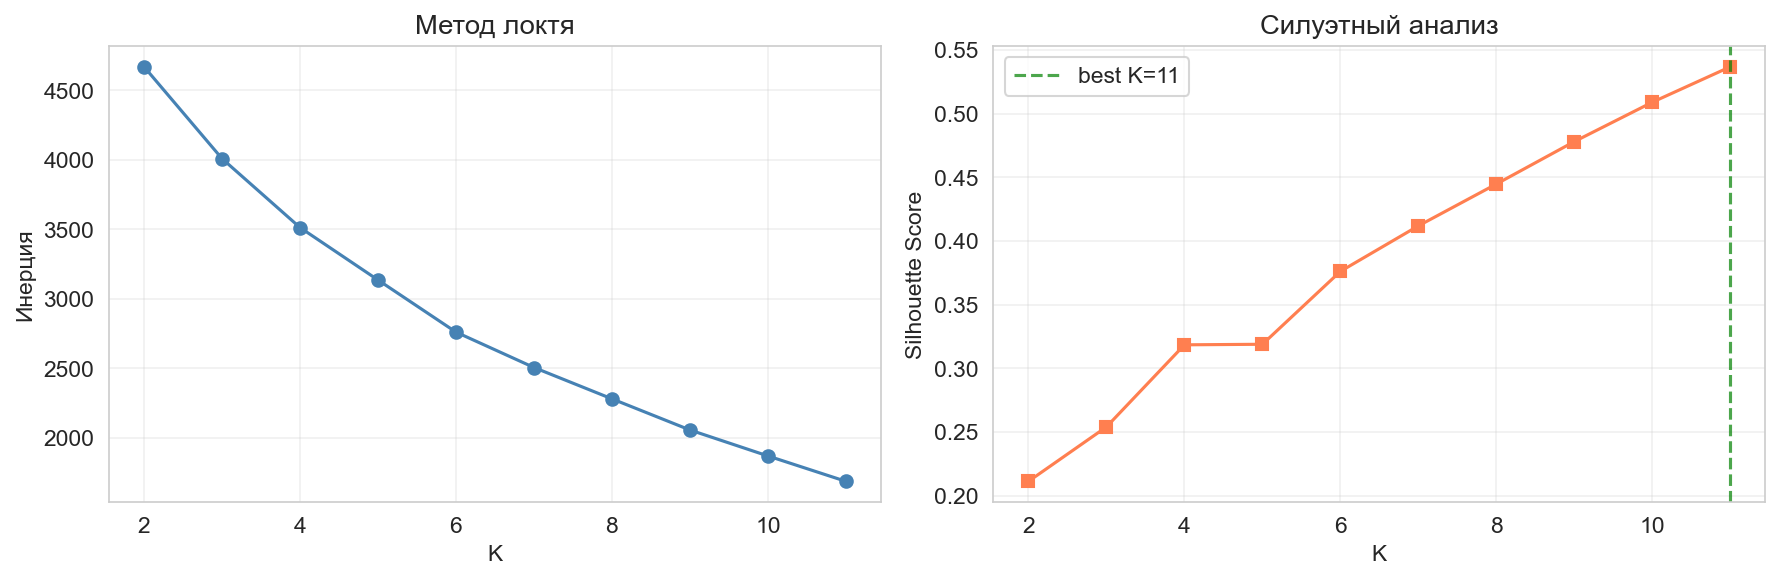


Silhouette scores:
  K=2: 0.2111
  K=3: 0.2539
  K=4: 0.3183
  K=5: 0.3188
  K=6: 0.3760
  K=7: 0.4118
  K=8: 0.4446
  K=9: 0.4780
  K=10: 0.5089
  K=11: 0.5367  <-- best

Выбран K=11 (максимальный Silhouette Score)


In [10]:
# --- Подготовка признаков для кластеризации ---
# Используем: log(Market_Cap) + one-hot ISIC секция
df_clust = df[(df['Market_Cap'] > 0) & df['has_isic']].copy()

# One-hot кодирование ISIC
isic_dummies = pd.get_dummies(df_clust['ISIC_Section'], prefix='ISIC')

# Признаки
clust_features = pd.DataFrame({
    'log_MCap': np.log(df_clust['Market_Cap'].values),
}, index=df_clust.index)
clust_features = pd.concat([clust_features, isic_dummies], axis=1)

# Масштабирование
scaler = RobustScaler()
X_scaled = scaler.fit_transform(clust_features)

print(f'Компаний для кластеризации: {len(clust_features)}')
print(f'Признаков: {X_scaled.shape[1]} (1 log_MCap + {isic_dummies.shape[1]} ISIC-секций)')

# --- Подбор оптимального K ---
k_range = range(2, 12)
inertias, sil_scores = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=3000, random_state=42))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(k_range), inertias, 'o-', color='steelblue')
ax1.set_xlabel('K'); ax1.set_ylabel('Инерция'); ax1.set_title('Метод локтя')
ax1.grid(True, alpha=0.3)

ax2.plot(list(k_range), sil_scores, 's-', color='coral')
ax2.set_xlabel('K'); ax2.set_ylabel('Silhouette Score'); ax2.set_title('Силуэтный анализ')
ax2.grid(True, alpha=0.3)
best_k = list(k_range)[np.argmax(sil_scores)]
ax2.axvline(best_k, color='green', linestyle='--', alpha=0.7, label=f'best K={best_k}')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '05_elbow_silhouette.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nSilhouette scores:')
for k, s in zip(k_range, sil_scores):
    print(f'  K={k}: {s:.4f}{"  <-- best" if k == best_k else ""}')

# Используем best_k из силуэтного анализа
FINAL_K = best_k
print(f'\nВыбран K={FINAL_K} (максимальный Silhouette Score)')

In [11]:
# --- Финальная кластеризация (K = best из силуэтного анализа) ---
kmeans_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=20)
df_clust['Cluster'] = kmeans_final.fit_predict(X_scaled)
sil = silhouette_score(X_scaled, df_clust['Cluster'], sample_size=3000, random_state=42)
print(f'K = {FINAL_K}, Silhouette = {sil:.4f}')
print()

# Профилирование кластеров
cluster_profile = df_clust.groupby('Cluster').agg(
    N=('Ticker', 'count'),
    Медиана_MCap_USD=('MCap_USD_B', 'median'),
    Средняя_MCap_USD=('MCap_USD_B', 'mean'),
    Топ_ISIC=('ISIC_Section', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else '?'),
    Топ_ISIC_доля=('ISIC_Section', lambda x: x.value_counts(normalize=True).iloc[0] * 100),
    Страна_мода=('Country', lambda x: x.mode().iloc[0]),
)
cluster_profile['Медиана_MCap_USD'] = cluster_profile['Медиана_MCap_USD'].apply(
    lambda x: f'${x*1000:,.0f}M' if x < 1 else f'${x:,.1f}B')
cluster_profile['Средняя_MCap_USD'] = cluster_profile['Средняя_MCap_USD'].apply(
    lambda x: f'${x*1000:,.0f}M' if x < 1 else f'${x:,.1f}B')
cluster_profile['Топ_ISIC_доля'] = cluster_profile['Топ_ISIC_доля'].apply(lambda x: f'{x:.0f}%')
cluster_profile.columns = ['Компаний', 'Медиана MCap', 'Средн. MCap',
                            'Основной ISIC', 'Доля ISIC', 'Осн. страна']

print('Профиль кластеров:')
display(cluster_profile)

# Распределение кластеров по странам
print('\nРаспределение кластеров по странам:')
display(pd.crosstab(df_clust['Cluster'], df_clust['Country_RU'],
                    margins=True, margins_name='Всего'))

K = 11, Silhouette = 0.5367

Профиль кластеров:


,Компаний,Медиана MCap,Средн. MCap,Основной ISIC,Доля ISIC,Осн. страна
Cluster,,,,,,
0,575,$44M,$289M,L,100%,Thailand
1,698,$14M,$223M,F,100%,Vietnam
2,241,$40M,$667M,D,100%,Vietnam
3,614,$17M,$432M,C,100%,Vietnam
4,392,$22M,$224M,S,49%,Malaysia
5,362,$24M,$726M,J,100%,Malaysia
6,634,$31M,$123M,C,100%,Malaysia
7,530,$47M,$1.1B,B,33%,Indonesia
8,303,$51M,$316M,A,100%,Thailand



Распределение кластеров по странам:


Country_RU,Вьетнам,Индонезия,Малайзия,Сингапур,Таиланд,Всего
Cluster,,,,,,
0,115,90,119,42,209,575
1,334,50,153,89,72,698
2,107,17,29,29,59,241
3,400,196,6,5,7,614
4,69,3,154,81,85,392
5,56,60,105,44,97,362
6,4,2,390,132,106,634
7,188,317,5,0,20,530
8,65,72,79,0,87,303


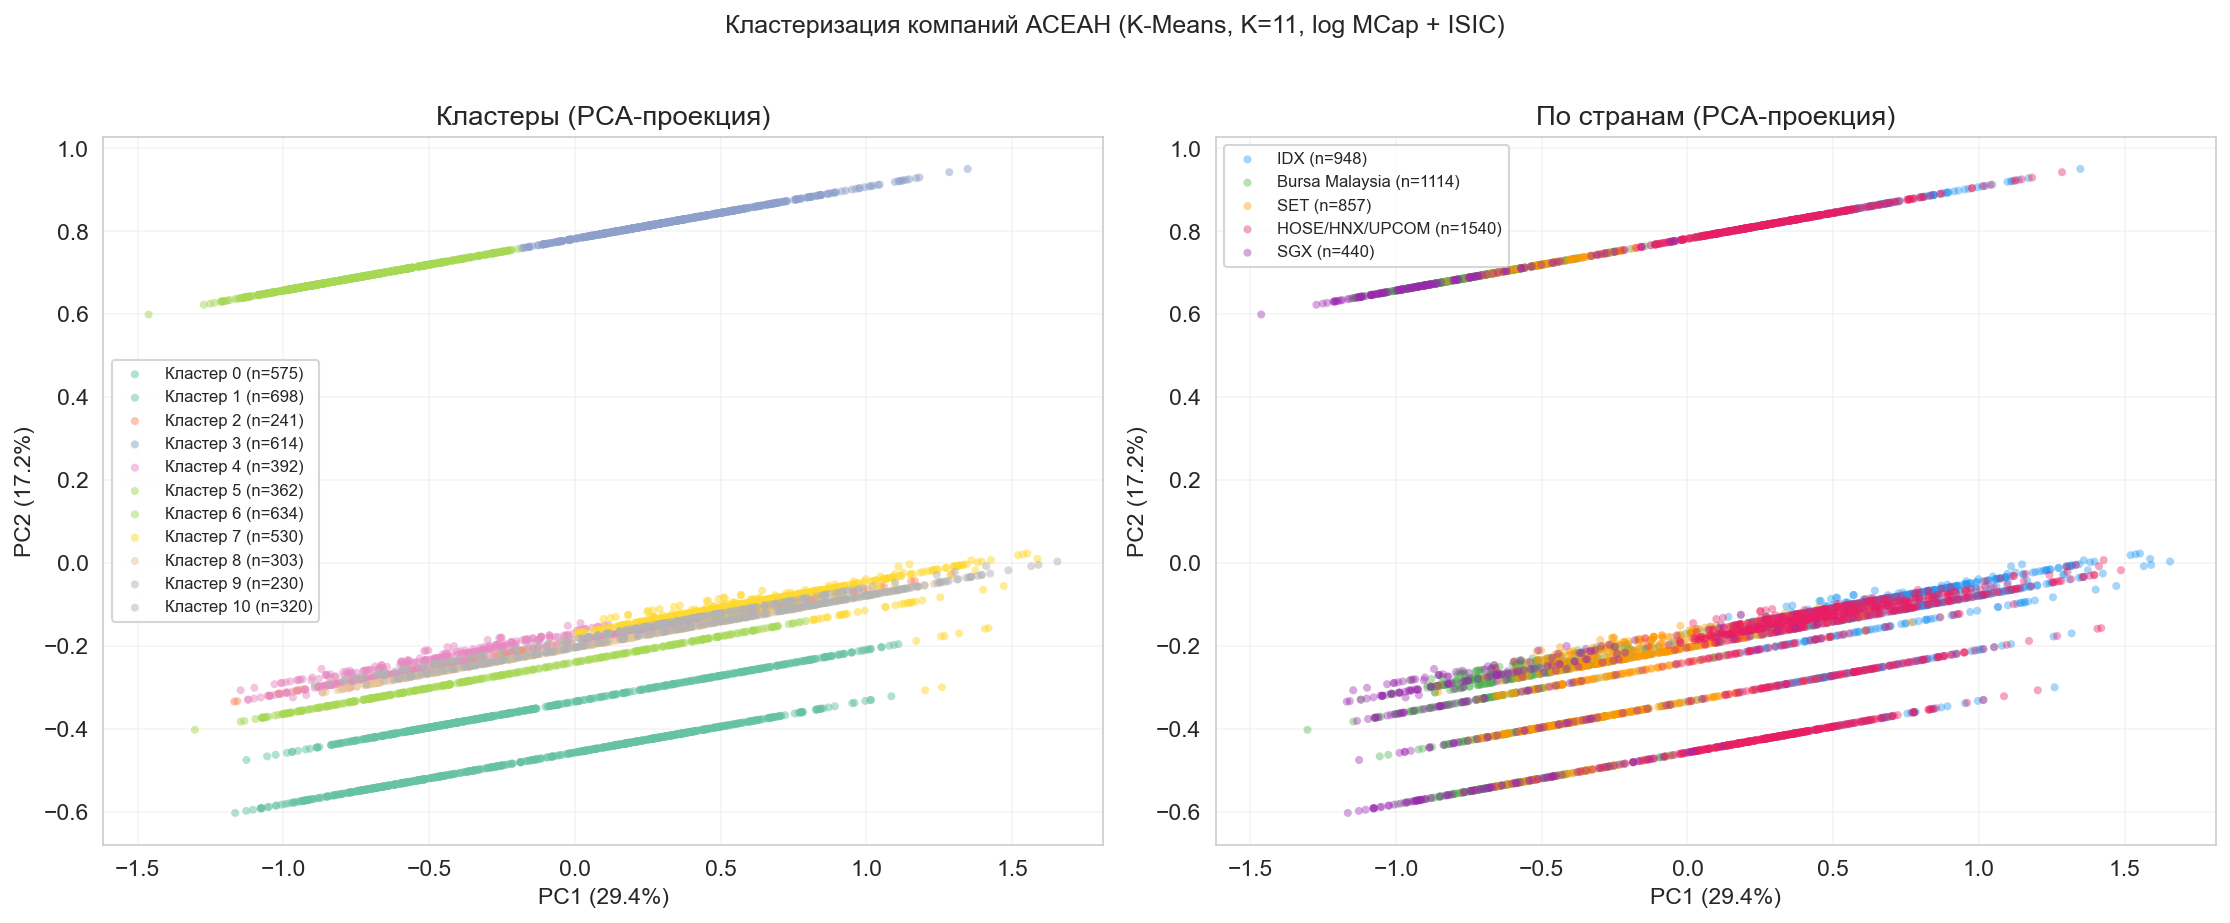

In [12]:
# --- PCA-визуализация кластеров ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_clust['PCA1'] = X_pca[:, 0]
df_clust['PCA2'] = X_pca[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
cluster_colors = plt.cm.Set2(np.linspace(0, 1, FINAL_K))

# Кластеры
for i in range(FINAL_K):
    mask = df_clust['Cluster'] == i
    ax1.scatter(df_clust.loc[mask, 'PCA1'], df_clust.loc[mask, 'PCA2'],
                c=[cluster_colors[i]], label=f'Кластер {i} (n={mask.sum()})',
                alpha=0.5, s=15, edgecolors='none')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax1.set_title('Кластеры (PCA-проекция)')
ax1.legend(fontsize=8, loc='best')
ax1.grid(True, alpha=0.2)

# По странам
for i, co in enumerate(COUNTRIES):
    mask = df_clust['Country'] == co
    ax2.scatter(df_clust.loc[mask, 'PCA1'], df_clust.loc[mask, 'PCA2'],
                c=[colors_country[i]], label=f'{EXCHANGE[co]} (n={mask.sum()})',
                alpha=0.4, s=15, edgecolors='none')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax2.set_title('По странам (PCA-проекция)')
ax2.legend(fontsize=8, loc='best')
ax2.grid(True, alpha=0.2)

plt.suptitle(f'Кластеризация компаний АСЕАН (K-Means, K={FINAL_K}, log MCap + ISIC)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '06_pca_clusters.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Блок 5. Секторы, релевантные для сотрудничества с Россией

In [13]:
# --- Секторы, связанные с товарными потоками Россия — АСЕАН ---
trade_sectors = {
    'A': 'Пальмовое масло, каучук, кофе, специи — ключевой импорт России из АСЕАН',
    'B': 'Нефть, газ, уголь, никель, олово — пересечение сырьевых интересов',
    'C': 'Обрабатывающая промышленность — потенциал для российского оборудования',
    'D': 'Энергетика — экспорт энергоресурсов и технологий из России',
    'H': 'Транспорт — логистика торговых потоков',
    'K': 'Финансы — расчёты в нац. валютах, корреспондентские связи',
}

df_trade = df_isic[df_isic['ISIC_Section'].isin(trade_sectors.keys())].copy()
print(f'Компании в торгово-релевантных секторах: {len(df_trade)} из {len(df_isic)}')
print(f'Капитализация: ${df_trade["MCap_USD_B"].sum():,.0f} млрд '
      f'({df_trade["MCap_USD_B"].sum() / df_isic["MCap_USD_B"].sum() * 100:.1f}%)')
print()

# Таблица по секторам × странам
trade_stats = []
for sec, desc in trade_sectors.items():
    sec_df = df_trade[df_trade['ISIC_Section'] == sec]
    row = {'ISIC': sec, 'Описание': ISIC_NAMES.get(sec, sec)[:30]}
    for co in COUNTRIES:
        co_sec = sec_df[sec_df['Country'] == co]
        row[f'{EXCHANGE[co]}_n'] = len(co_sec)
        row[f'{EXCHANGE[co]}_mcap'] = co_sec['MCap_USD_B'].sum()
    row['Всего_n'] = len(sec_df)
    row['Всего_mcap'] = sec_df['MCap_USD_B'].sum()
    trade_stats.append(row)

trade_df = pd.DataFrame(trade_stats)
print('Торгово-релевантные секторы АСЕАН:')
for _, r in trade_df.iterrows():
    print(f'\n  {r["ISIC"]} — {r["Описание"]} ({r["Всего_n"]} компаний, ${r["Всего_mcap"]:,.0f} млрд)')
    print(f'     {trade_sectors[r["ISIC"]][:80]}')
    for co in COUNTRIES:
        n = r[f'{EXCHANGE[co]}_n']
        m = r[f'{EXCHANGE[co]}_mcap']
        if n > 0:
            print(f'     {EXCHANGE[co]:20s}: {n:4d} комп. / ${m:,.1f} млрд')

Компании в торгово-релевантных секторах: 2697 из 5151
Капитализация: $1,659 млрд (62.6%)

Торгово-релевантные секторы АСЕАН:

  A — Сельское хозяйство (310 компаний, $96 млрд)
     Пальмовое масло, каучук, кофе, специи — ключевой импорт России из АСЕАН
     IDX                 :   72 комп. / $30.2 млрд
     Bursa Malaysia      :   79 комп. / $39.2 млрд
     SET                 :   87 комп. / $23.7 млрд
     HOSE/HNX/UPCOM      :   65 комп. / $2.8 млрд
     SGX                 :    7 комп. / $0.0 млрд

  B — Добыча полезных ископаемых (208 компаний, $196 млрд)
     Нефть, газ, уголь, никель, олово — пересечение сырьевых интересов
     IDX                 :  127 комп. / $184.8 млрд
     Bursa Malaysia      :    3 комп. / $0.8 млрд
     SET                 :    5 комп. / $0.0 млрд
     HOSE/HNX/UPCOM      :   49 комп. / $8.7 млрд
     SGX                 :   24 комп. / $1.7 млрд

  C — Обрабатывающая промышленность (1276 компаний, $343 млрд)
     Обрабатывающая промышленность — потенциал 

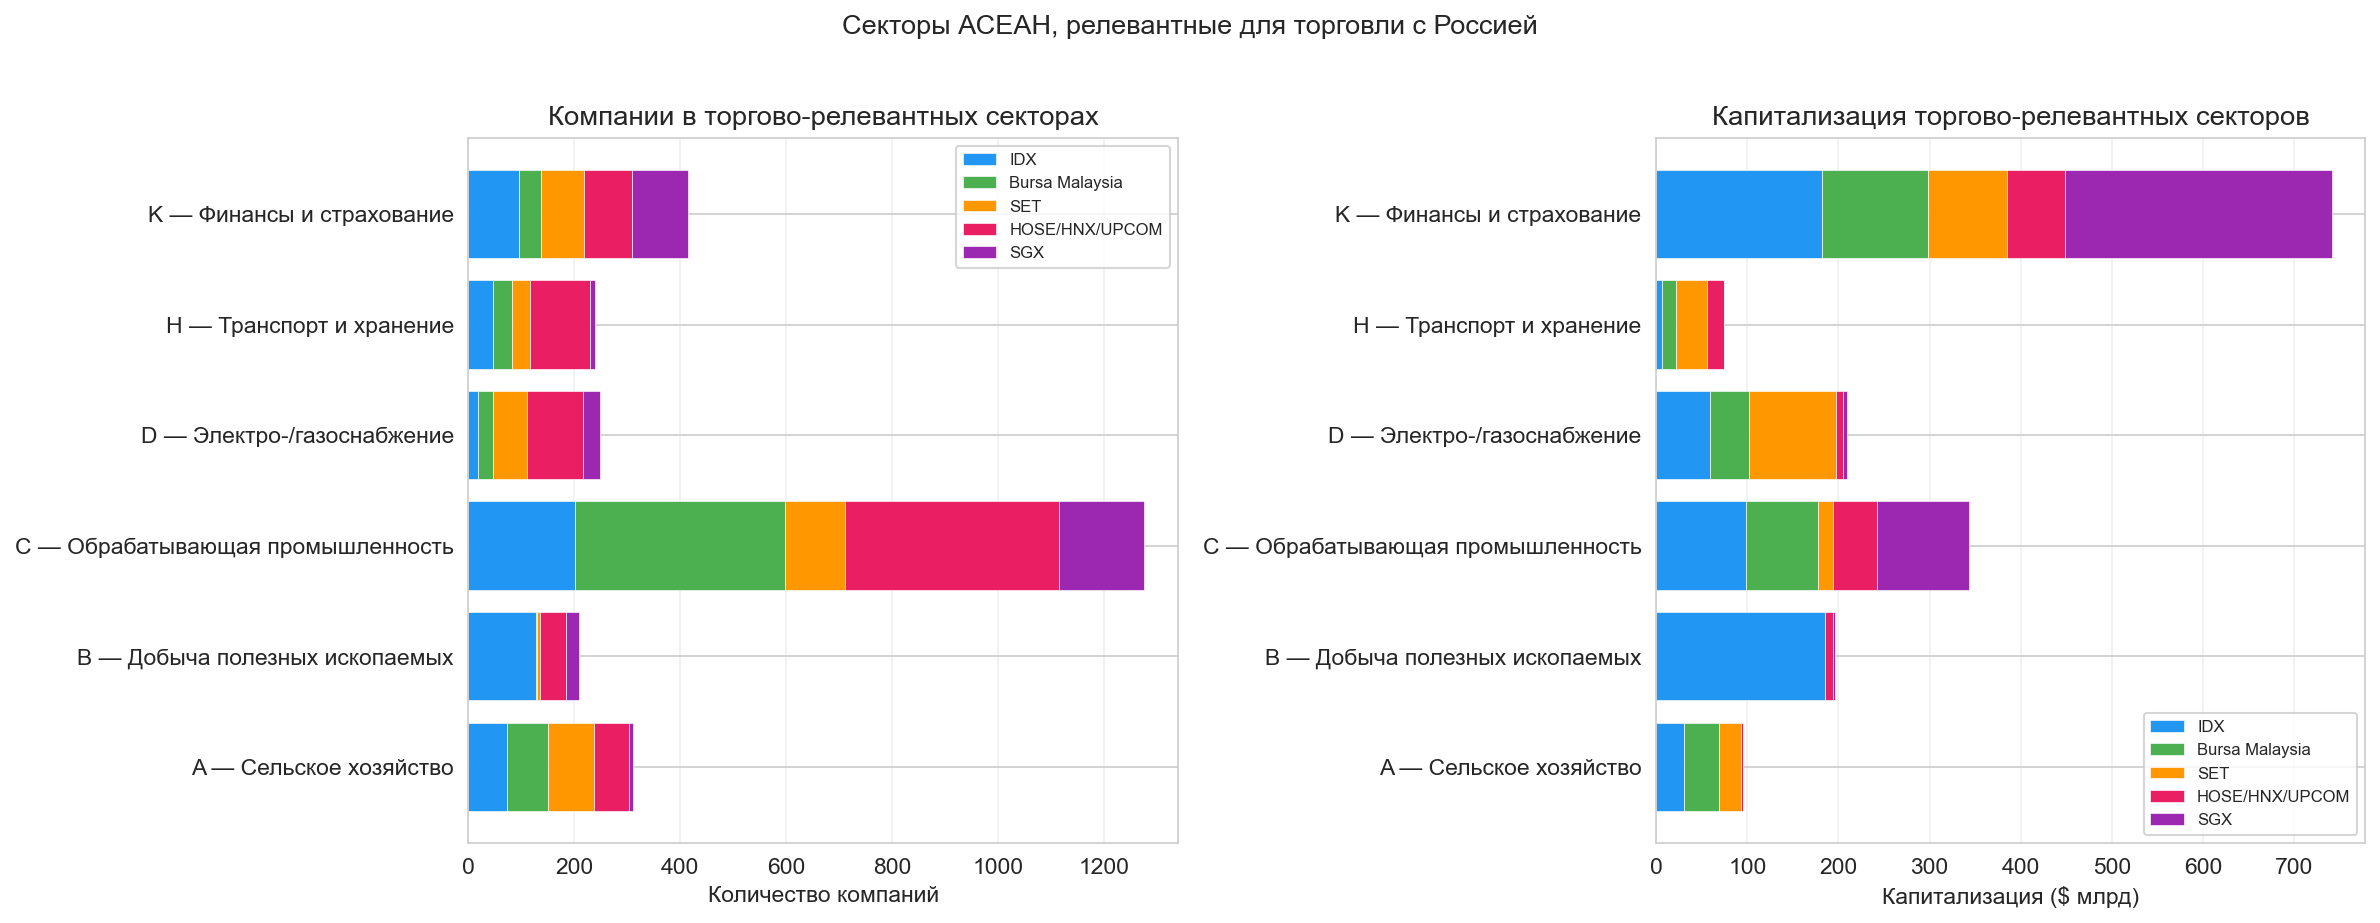

In [14]:
# --- Визуализация торгово-релевантных секторов ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sec_order = list(trade_sectors.keys())
sec_labels = [f'{s} — {ISIC_NAMES[s]}' for s in sec_order]

# Количество компаний по секторам × страна
bottom = np.zeros(len(sec_order))
for i, co in enumerate(COUNTRIES):
    vals = [len(df_trade[(df_trade['ISIC_Section'] == s) & (df_trade['Country'] == co)]) for s in sec_order]
    ax1.barh(sec_labels, vals, left=bottom, color=colors_country[i],
             label=EXCHANGE[co], edgecolor='white', linewidth=0.3)
    bottom += np.array(vals)
ax1.set_xlabel('Количество компаний')
ax1.set_title('Компании в торгово-релевантных секторах')
ax1.legend(fontsize=8)
ax1.grid(axis='x', alpha=0.3)

# Капитализация
bottom = np.zeros(len(sec_order))
for i, co in enumerate(COUNTRIES):
    vals = [df_trade[(df_trade['ISIC_Section'] == s) & (df_trade['Country'] == co)]['MCap_USD_B'].sum()
            for s in sec_order]
    ax2.barh(sec_labels, vals, left=bottom, color=colors_country[i],
             label=EXCHANGE[co], edgecolor='white', linewidth=0.3)
    bottom += np.array(vals)
ax2.set_xlabel('Капитализация ($ млрд)')
ax2.set_title('Капитализация торгово-релевантных секторов')
ax2.legend(fontsize=8)
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('Секторы АСЕАН, релевантные для торговли с Россией', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '07_trade_sectors.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Блок 6. Косинусная близость с Россией

Косинусная близость секторальных профилей с товарной структурой России:


,Страна,Cosine similarity,C (%),B (%),D (%),K (%),J (%),F (%),H (%),A (%),L (%),Q (%)
Биржа,,,,,,,,,,,,
IDX,Индонезия,0.885,21.2,13.3,1.9,9.9,8.8,5.3,4.9,7.5,9.6,2.4
Bursa Malaysia,Малайзия,0.691,35.5,0.3,2.6,3.8,9.4,13.7,3.1,7.1,10.7,1.2
HOSE/HNX/UPCOM,Вьетнам,0.677,26.2,3.2,6.9,5.8,4.0,21.7,7.3,4.2,7.7,0.6
SGX,Сингапур,0.677,24.0,3.6,4.8,16.0,7.6,14.2,1.3,1.0,10.1,4.8
SET,Таиланд,0.486,13.0,0.6,7.2,9.4,11.4,8.4,4.0,10.0,24.6,4.1
Россия (веса),,1.000,30.0,28.0,10.0,8.0,3.0,2.0,5.0,12.0,1.0,1.0


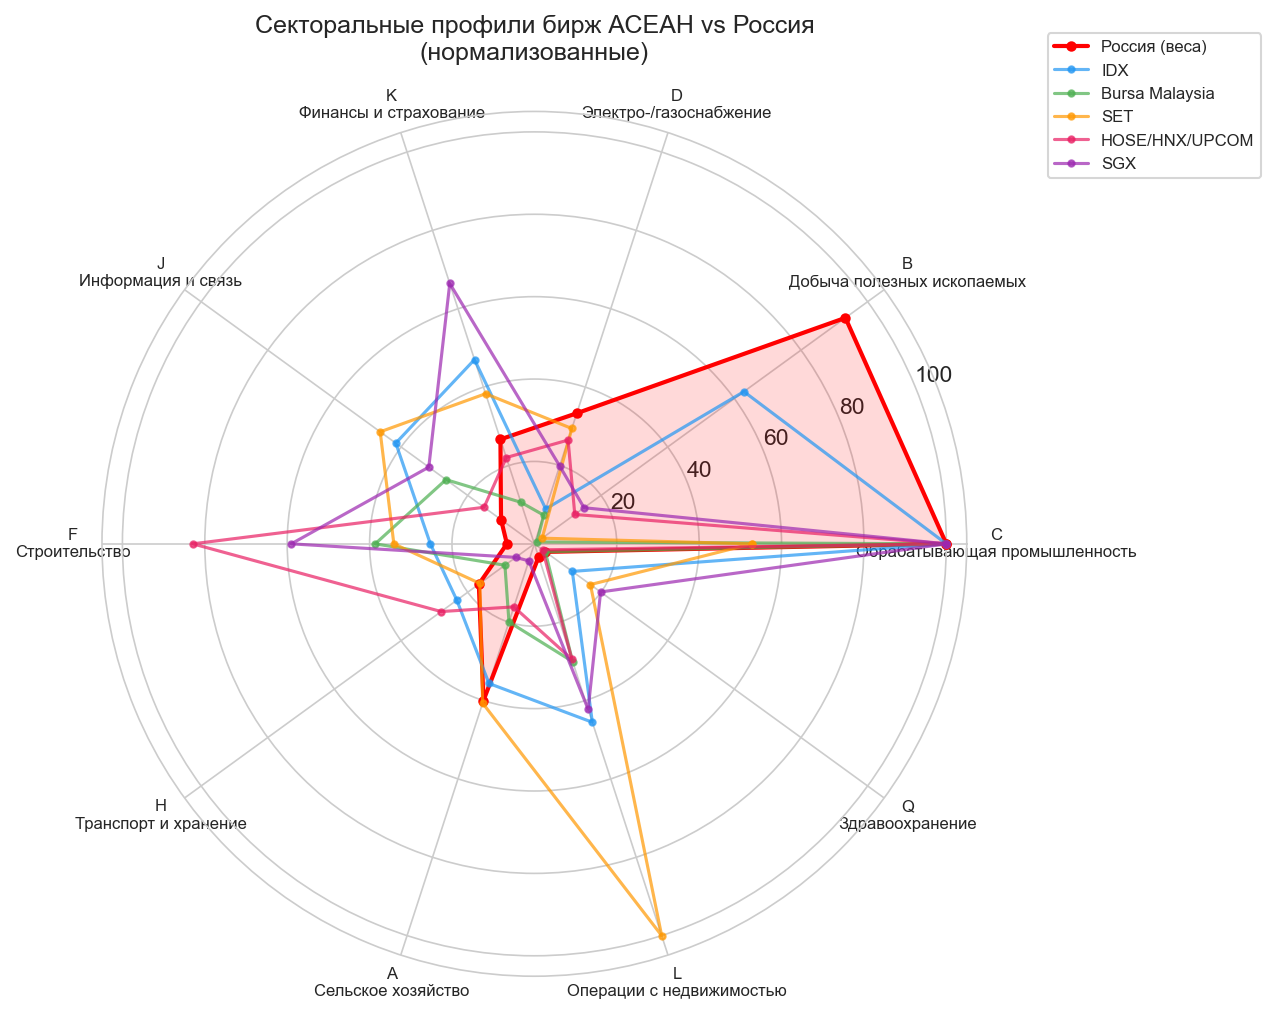

In [15]:
# --- Косинусная близость секторальных профилей с Россией ---
from numpy.linalg import norm

# Веса России на основе товарной структуры экспорта/импорта Россия-Индонезия
# (UN Comtrade, Самандраков 2025: HS27→B 38.1%, HS31 удобрения→C 23.5%,
#  HS72 металлы→C 20.2%, HS10 зерновые→A 8.2%, HS15 масла→A 59.4%)
top_isic = ['C', 'B', 'D', 'K', 'J', 'F', 'H', 'A', 'L', 'Q']
RUSSIA_W = {
    'C': 30,   # Обрабатывающая: удобрения HS31 (23.5%), металлы HS72 (20.2%)
    'B': 28,   # Добыча: нефть/газ/уголь HS27 (38.1% импорта Индонезии из РФ)
    'A': 12,   # Сельское хозяйство: зерновые (8.2%), пальмовое масло (59.4%)
    'D': 10,   # Энергетика: электро-/газоснабжение
    'K': 8,    # Финансы: расчёты в нац. валютах, ЕАЭС
    'H': 5,    # Транспорт: логистика торговых потоков
    'J': 3,    # ИКТ: цифровые технологии
    'F': 2,    # Строительство: инфраструктура
    'L': 1,    # Недвижимость
    'Q': 1,    # Здравоохранение: фармацевтика
}
russia_vec = np.array([RUSSIA_W[s] for s in top_isic], dtype=float)

cosine_results = []
country_vecs = {}
for co in COUNTRIES:
    co_df = df_isic[df_isic['Country'] == co]
    total = len(co_df)
    vec = np.array([len(co_df[co_df['ISIC_Section'] == s]) / total * 100 for s in top_isic])
    cos_sim = np.dot(vec, russia_vec) / (norm(vec) * norm(russia_vec) + 1e-10)
    country_vecs[co] = vec
    cosine_results.append({
        'Биржа': EXCHANGE[co], 'Страна': COUNTRY_RU[co],
        'Cosine similarity': round(cos_sim, 3),
        **{f'{s} (%)': round(v, 1) for s, v in zip(top_isic, vec)}
    })

cos_df = pd.DataFrame(cosine_results).sort_values('Cosine similarity', ascending=False)
cos_df.loc[len(cos_df)] = ['Россия (веса)', '', 1.000] + [RUSSIA_W[s] for s in top_isic]

print('Косинусная близость секторальных профилей с товарной структурой России:')
display(cos_df.set_index('Биржа'))

# Radar chart
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
angles = np.linspace(0, 2 * np.pi, len(top_isic), endpoint=False).tolist()
angles += angles[:1]

# Россия
rv = (russia_vec / russia_vec.max() * 100).tolist()
rv += rv[:1]
ax.fill(angles, rv, alpha=0.15, color='red')
ax.plot(angles, rv, 'o-', color='red', linewidth=2, label='Россия (веса)', markersize=4)

for i, co in enumerate(COUNTRIES):
    vec = country_vecs[co]
    vec_norm = (vec / vec.max() * 100).tolist()
    vec_norm += vec_norm[:1]
    ax.plot(angles, vec_norm, 'o-', color=colors_country[i],
            linewidth=1.5, label=EXCHANGE[co], markersize=3, alpha=0.7)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([f'{s}\n{ISIC_NAMES[s]}' for s in top_isic], fontsize=8)
ax.set_title('Секторальные профили бирж АСЕАН vs Россия\n(нормализованные)', fontsize=12, pad=25)
ax.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '08_cosine_radar.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Блок 7. Углублённый анализ Индонезии (IDX) — Revenue, прибыль, FCF

In [16]:
# --- Индонезийские компании с финансовыми данными ---
df_idx = df[(df['Country'] == 'Indonesia') & (df['Revenue'] > 0) & (df['Market_Cap'] > 0)].copy()

# Клиппинг экстремальных маржей
df_idx['Profit_Margin'] = df_idx['Profit_Margin'].clip(-200, 200)
df_idx['FCF_Margin'] = df_idx['FCF_Margin'].clip(-200, 200)
df_idx['Revenue_Growth'] = df_idx['Revenue_Growth'].clip(-100, 500)

print(f'IDX компаний с Revenue/Income/FCF: {len(df_idx)}')
print(f'Прибыльных: {(df_idx["Is_Profitable"] == 1).sum()} ({(df_idx["Is_Profitable"] == 1).mean()*100:.1f}%)')
print()

# Секторальный профиль IDX
idx_sectors = df_idx.groupby('Sector').agg(
    N=('Ticker', 'count'),
    Общая_кап_T=('Market_Cap', lambda x: x.sum() / 1e12),
    Медиана_кап_B=('Market_Cap', lambda x: x.median() / 1e9),
    Медиана_выручки_B=('Revenue', lambda x: x.median() / 1e9),
    Медиана_роста=('Revenue_Growth', 'median'),
    Медиана_маржи=('Profit_Margin', 'median'),
    Медиана_FCF_маржи=('FCF_Margin', 'median'),
    Доля_прибыльных=('Is_Profitable', 'mean'),
).sort_values('Общая_кап_T', ascending=False)

# Форматирование
fmt = idx_sectors.copy()
fmt['Общая_кап_T'] = fmt['Общая_кап_T'].apply(lambda x: f'{x:,.1f}T')
fmt['Медиана_кап_B'] = fmt['Медиана_кап_B'].apply(lambda x: f'{x:,.0f}B')
fmt['Медиана_выручки_B'] = fmt['Медиана_выручки_B'].apply(lambda x: f'{x:,.0f}B')
fmt['Медиана_роста'] = fmt['Медиана_роста'].apply(lambda x: f'{x:.1f}%')
fmt['Медиана_маржи'] = fmt['Медиана_маржи'].apply(lambda x: f'{x:.1f}%')
fmt['Медиана_FCF_маржи'] = fmt['Медиана_FCF_маржи'].apply(lambda x: f'{x:.1f}%')
fmt['Доля_прибыльных'] = fmt['Доля_прибыльных'].apply(lambda x: f'{x:.0%}')
fmt.columns = ['Комп.', 'Кап.(трлн IDR)', 'Мед.кап.(млрд)', 'Мед.выр.(млрд)',
               'Мед.рост', 'Мед.маржа', 'Мед.FCF маржа', 'Приб.']

print('Секторальный профиль IDX (медианные значения):')
display(fmt)

IDX компаний с Revenue/Income/FCF: 896
Прибыльных: 633 (70.6%)

Секторальный профиль IDX (медианные значения):


,Комп.,Кап.(трлн IDR),Мед.кап.(млрд),Мед.выр.(млрд),Мед.рост,Мед.маржа,Мед.FCF маржа,Приб.
Sector,,,,,,,,
Keuangan,101,"3,061.8T","3,133B",905B,7.2%,16.9%,-11.0%,88%
Barang Baku,106,"1,914.4T",873B,"1,775B",2.8%,2.5%,3.4%,71%
Energi,84,"1,855.5T","2,826B","1,840B",2.4%,6.0%,2.5%,82%
Infrastruktur,65,"1,764.9T","1,856B","1,220B",0.5%,8.4%,10.5%,71%
Barang Konsumen Primer,128,"1,023.6T","1,464B","1,985B",5.6%,3.1%,2.8%,72%
Teknologi,43,762.1T,510B,842B,-2.4%,2.4%,-0.1%,65%
Perindustrian,64,521.2T,424B,393B,2.0%,3.1%,4.9%,66%
Properti & Real Estat,82,514.1T,875B,152B,1.4%,8.3%,2.6%,67%
Kesehatan,37,424.2T,"1,600B","1,410B",10.8%,4.1%,0.1%,65%


IDX кластеризация: K=4, Silhouette=0.6060, N=896

Профиль кластеров IDX (медианы):


,N,Капитализация,Выручка,Рост,Чистая прибыль,FCF,Маржа,FCF маржа,Прибыльных
Cluster,,,,,,,,,
0,786,1.2T,1.1T,3.5%,34.2B,19.9B,4.6%,3.9%,74%
1,51,2.7T,562.4B,7.3%,71.1B,-1.3T,16.9%,-164.6%,78%
2,46,464.2B,12.1B,-35.9%,-30.8B,-8.3B,-165.2%,-72.1%,0%
3,13,371.6B,48.1B,500.0%,3.7B,-32.3B,7.7%,-14.0%,77%


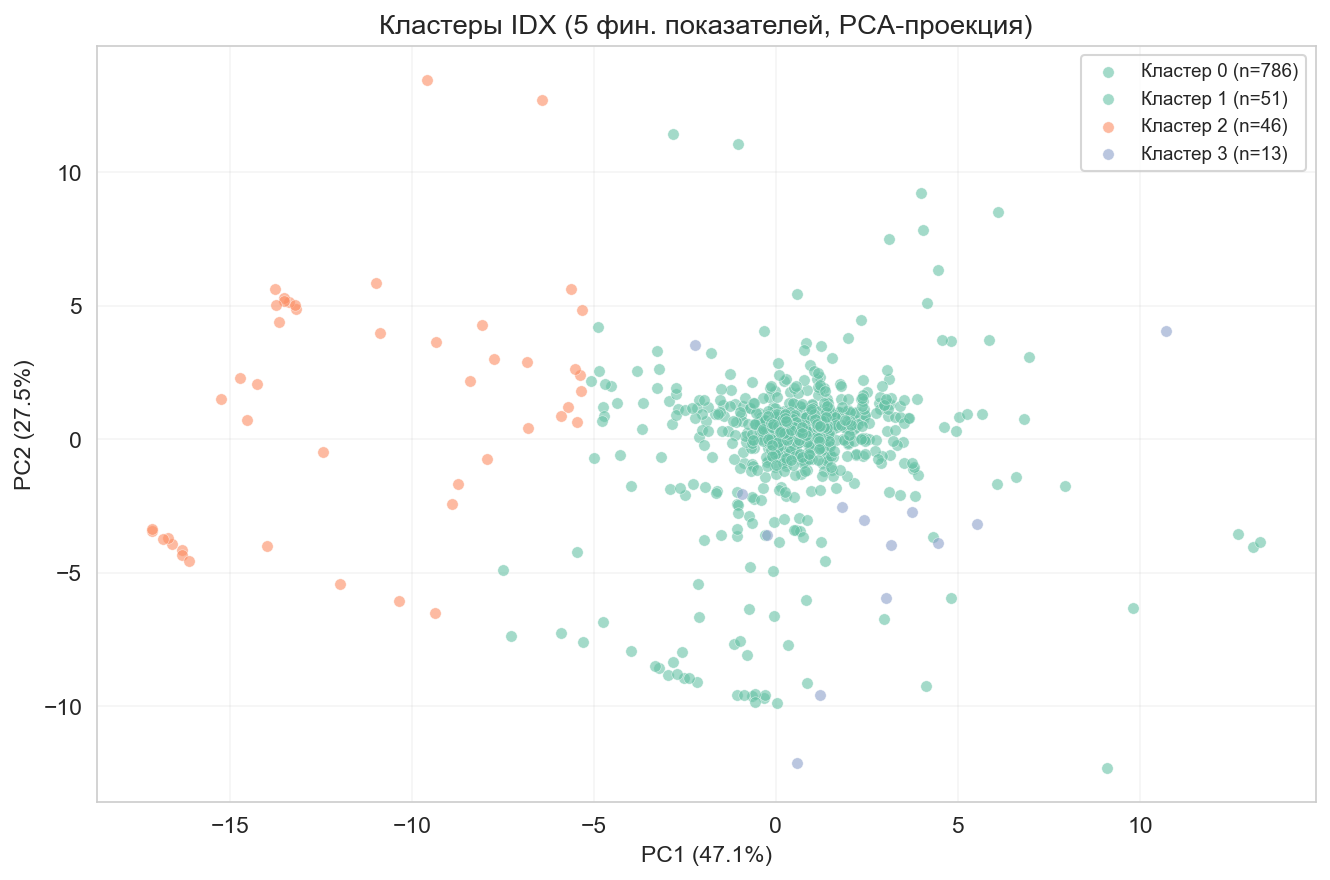

In [17]:
# --- Кластеризация IDX (с финансовыми показателями) ---
idx_clust_features = pd.DataFrame({
    'log_MCap': np.log(df_idx['Market_Cap']),
    'log_Revenue': np.log(df_idx['Revenue']),
    'Rev_Growth': df_idx['Revenue_Growth'].fillna(0),
    'Profit_Margin': df_idx['Profit_Margin'].fillna(0),
    'FCF_Margin': df_idx['FCF_Margin'].fillna(0),
}, index=df_idx.index).dropna()

scaler_idx = RobustScaler()
X_idx = scaler_idx.fit_transform(idx_clust_features)
df_idx_c = df_idx.loc[idx_clust_features.index].copy()

# K=4 (как в оригинале)
km_idx = KMeans(n_clusters=4, random_state=42, n_init=20)
df_idx_c['Cluster'] = km_idx.fit_predict(X_idx)
sil_idx = silhouette_score(X_idx, df_idx_c['Cluster'])
print(f'IDX кластеризация: K=4, Silhouette={sil_idx:.4f}, N={len(df_idx_c)}')

# Профилирование
def fmt_idr(val):
    if abs(val) >= 1e12: return f'{val/1e12:.1f}T'
    elif abs(val) >= 1e9: return f'{val/1e9:.1f}B'
    elif abs(val) >= 1e6: return f'{val/1e6:.1f}M'
    return f'{val:.0f}'

idx_profile = df_idx_c.groupby('Cluster').agg({
    'Ticker': 'count',
    'Market_Cap': 'median', 'Revenue': 'median',
    'Revenue_Growth': 'median', 'Net_Income': 'median',
    'Free_Cash_Flow': 'median', 'Profit_Margin': 'median',
    'FCF_Margin': 'median', 'Is_Profitable': 'mean',
})

dp = idx_profile.copy()
for col in ['Market_Cap', 'Revenue', 'Net_Income', 'Free_Cash_Flow']:
    dp[col] = dp[col].apply(fmt_idr)
dp['Revenue_Growth'] = dp['Revenue_Growth'].apply(lambda x: f'{x:.1f}%')
dp['Profit_Margin'] = dp['Profit_Margin'].apply(lambda x: f'{x:.1f}%')
dp['FCF_Margin'] = dp['FCF_Margin'].apply(lambda x: f'{x:.1f}%')
dp['Is_Profitable'] = dp['Is_Profitable'].apply(lambda x: f'{x:.0%}')
dp.columns = ['N', 'Капитализация', 'Выручка', 'Рост', 'Чистая прибыль',
              'FCF', 'Маржа', 'FCF маржа', 'Прибыльных']

print('\nПрофиль кластеров IDX (медианы):')
display(dp)

# PCA
pca_idx = PCA(n_components=2)
X_pca_idx = pca_idx.fit_transform(X_idx)

fig, ax = plt.subplots(figsize=(9, 6))
for i in range(4):
    mask = df_idx_c['Cluster'] == i
    ax.scatter(X_pca_idx[mask, 0], X_pca_idx[mask, 1],
               c=[cluster_colors[i]], label=f'Кластер {i} (n={mask.sum()})',
               alpha=0.6, s=30, edgecolors='white', linewidth=0.3)
ax.set_xlabel(f'PC1 ({pca_idx.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_idx.explained_variance_ratio_[1]:.1%})')
ax.set_title('Кластеры IDX (5 фин. показателей, PCA-проекция)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '09_idx_clusters_pca.png'), dpi=150, bbox_inches='tight')
plt.show()

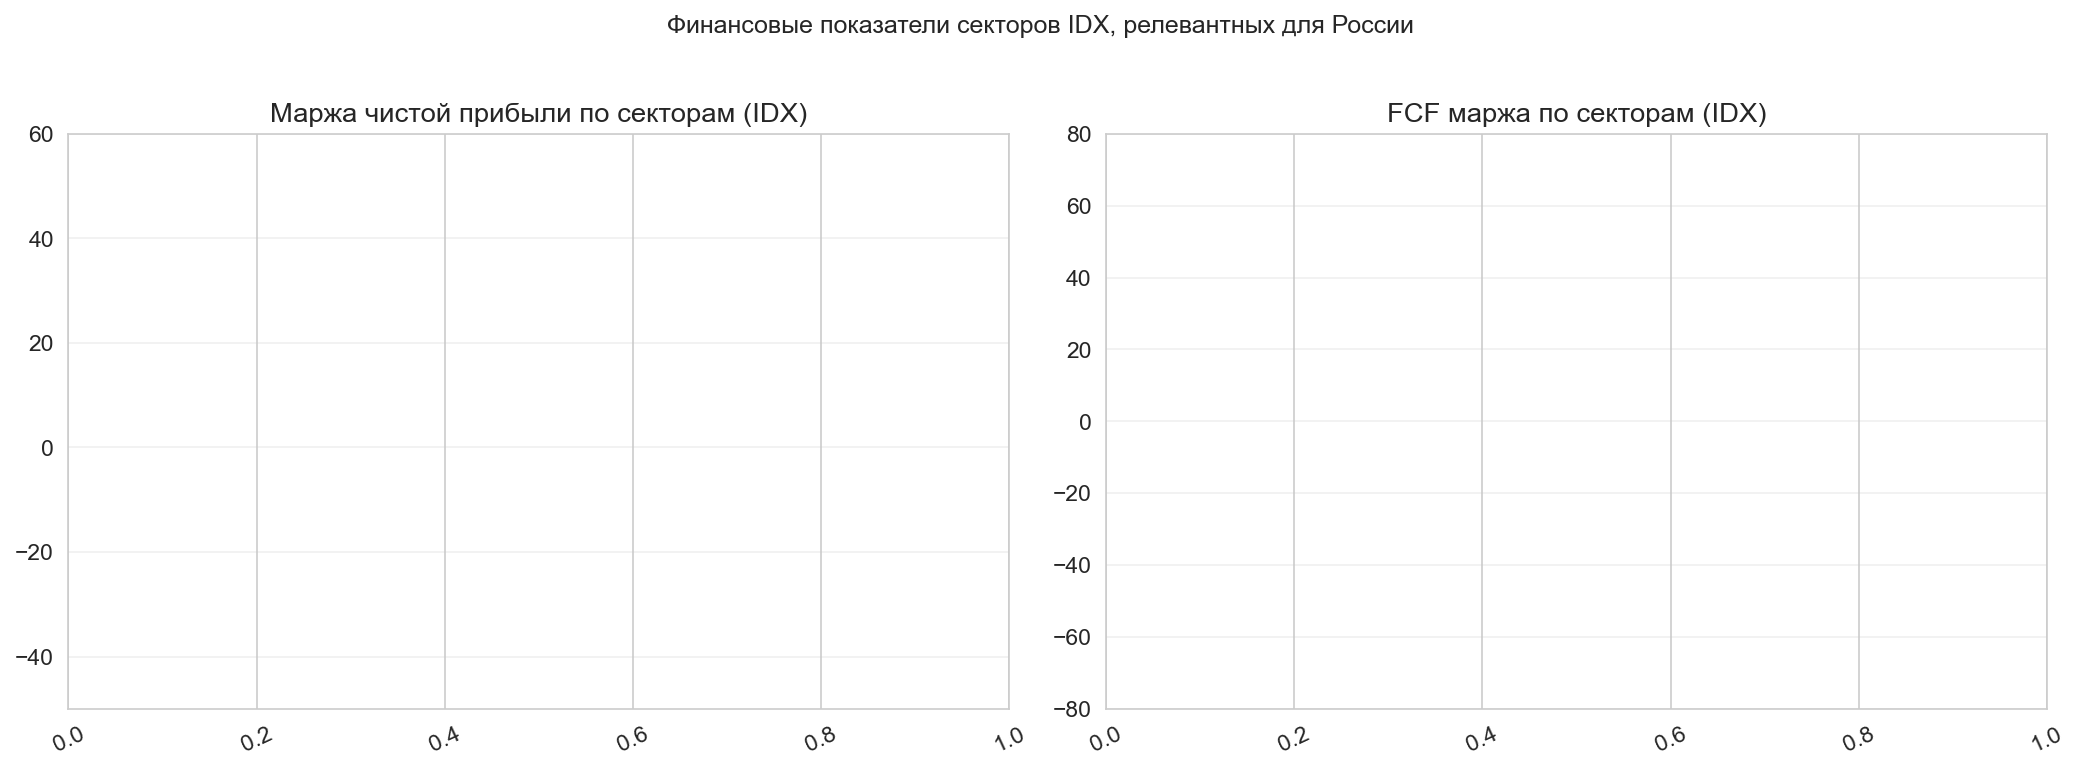

In [18]:
# --- Топ-компании IDX по секторам, релевантным для России ---
russia_sectors_idx = ['Energy', 'Materials', 'Industrials', 'Financials', 'Consumer Staples']

for sector in russia_sectors_idx:
    sec_df = df_idx_c[df_idx_c['Sector'] == sector]
    if len(sec_df) == 0:
        continue
    print(f'\n{"=" * 70}')
    print(f'{sector.upper()} ({len(sec_df)} компаний, капитализация {fmt_idr(sec_df["Market_Cap"].sum())})')
    print(f'{"=" * 70}')

    top5 = sec_df.nlargest(5, 'Market_Cap')[
        ['Ticker', 'Full Company Name', 'Industry', 'Market_Cap', 'Revenue',
         'Revenue_Growth', 'Profit_Margin']].copy()
    top5['Market_Cap'] = top5['Market_Cap'].apply(fmt_idr)
    top5['Revenue'] = top5['Revenue'].apply(fmt_idr)
    top5['Revenue_Growth'] = top5['Revenue_Growth'].apply(lambda x: f'{x:.1f}%' if pd.notna(x) else '—')
    top5['Profit_Margin'] = top5['Profit_Margin'].apply(lambda x: f'{x:.1f}%' if pd.notna(x) else '—')
    top5.columns = ['Тикер', 'Компания', 'Отрасль', 'Кап.', 'Выручка', 'Рост', 'Маржа']
    display(top5.reset_index(drop=True))

# Boxplot маржинальности
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
rel_idx = df_idx_c[df_idx_c['Sector'].isin(russia_sectors_idx)]

sns.boxplot(data=rel_idx, x='Sector', y='Profit_Margin', order=russia_sectors_idx,
            palette='Set2', ax=ax1, showfliers=False)
ax1.set_title('Маржа чистой прибыли по секторам (IDX)')
ax1.set_ylim(-50, 60)
ax1.tick_params(axis='x', rotation=25)
ax1.grid(axis='y', alpha=0.3)
ax1.set_xlabel('')

sns.boxplot(data=rel_idx, x='Sector', y='FCF_Margin', order=russia_sectors_idx,
            palette='Set2', ax=ax2, showfliers=False)
ax2.set_title('FCF маржа по секторам (IDX)')
ax2.set_ylim(-80, 80)
ax2.tick_params(axis='x', rotation=25)
ax2.grid(axis='y', alpha=0.3)
ax2.set_xlabel('')

plt.suptitle('Финансовые показатели секторов IDX, релевантных для России', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '10_idx_sectors_margins.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Блок 8. Малайзия — P/E и дивидендная доходность

Bursa Malaysia: 1116 компаний с капитализацией
  С P/E (0–200): 778
  С дивидендами: 548

Секторальные мультипликаторы Bursa Malaysia:


,N (P/E),Мед. P/E,Ср. P/E,N (Div),Мед. Div%,Ср. Div%
ISIC_Section,,,,,,
C — Обрабатывающая промышленн,262,13.6,20.8,200,3.77%,5.40%
F — Строительство,115,13.1,21.8,65,2.92%,3.79%
L — Операции с недвижимостью,96,11.3,16.8,62,4.56%,5.43%
J — Информация и связь,68,18.2,29.8,38,4.06%,4.45%
A — Сельское хозяйство,56,10.3,15.1,50,3.64%,4.22%
S — Прочие услуги,50,13.9,20.4,36,3.37%,3.69%
K — Финансы и страхование,36,12.5,18.0,29,4.42%,4.35%
D — Электро-/газоснабжение,24,18.2,18.8,14,3.09%,3.26%
H — Транспорт и хранение,24,13.5,27.7,13,3.64%,3.80%


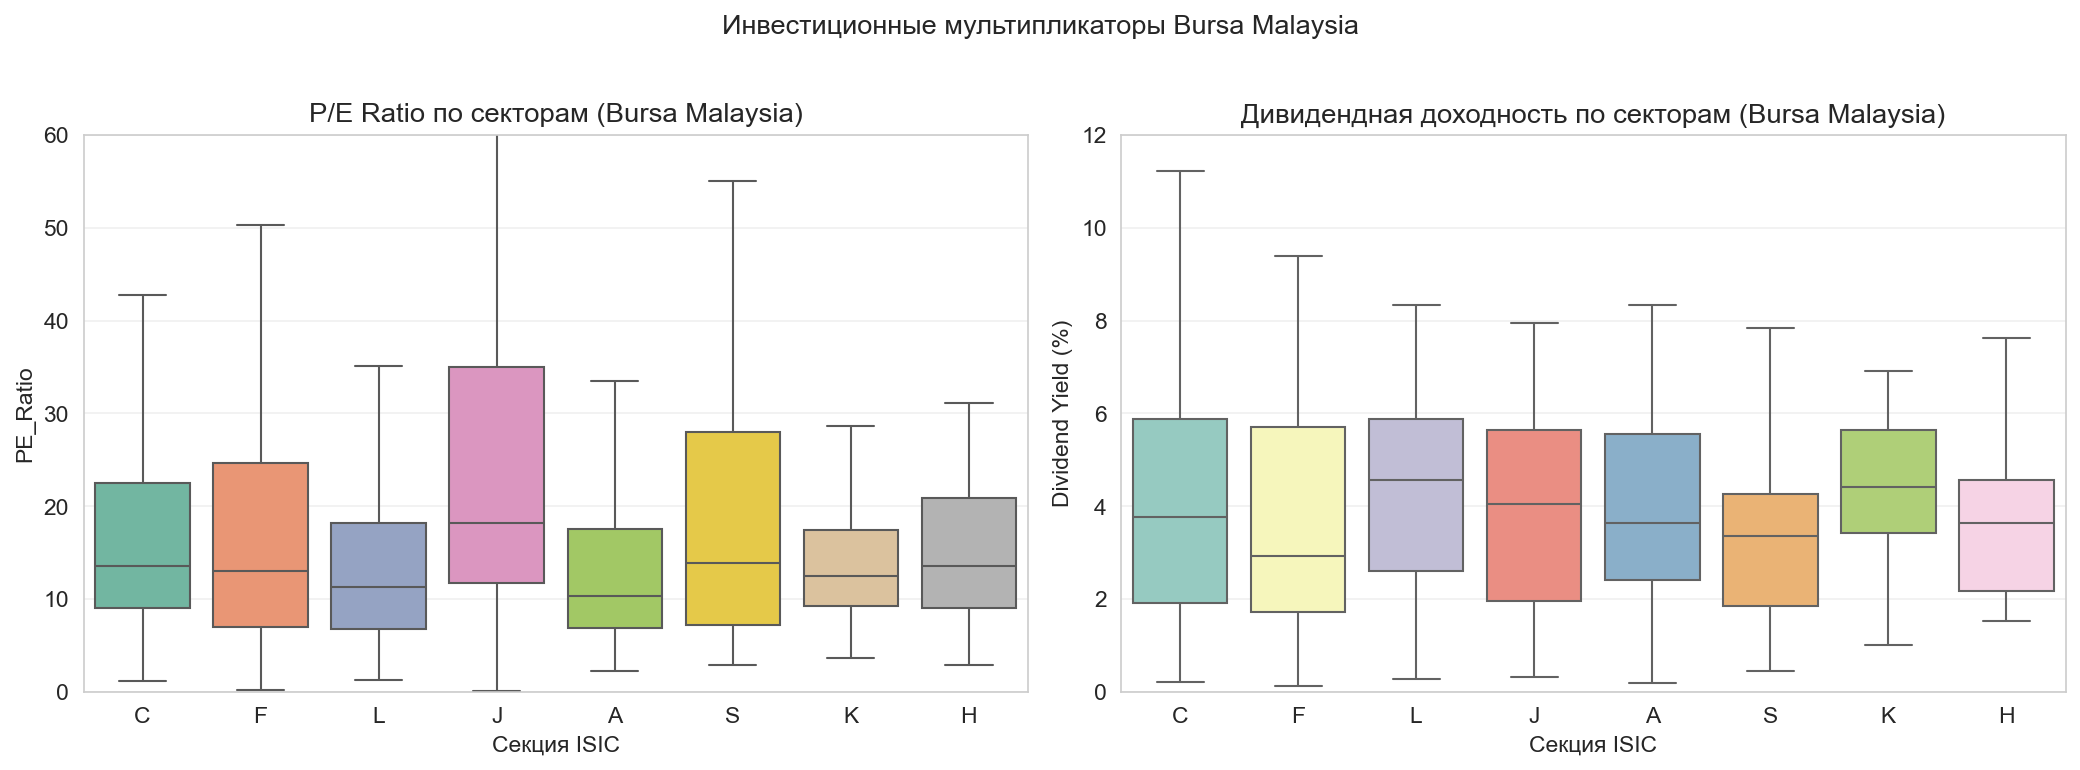

In [19]:
# --- Анализ Bursa Malaysia: P/E и Dividend Yield по секторам ---
df_my = df[(df['Country'] == 'Malaysia') & (df['Market_Cap'] > 0)].copy()
df_my['PE_Ratio'] = pd.to_numeric(df_my['PE_Ratio'], errors='coerce')
df_my['Dividend_Yield'] = pd.to_numeric(df_my['Dividend_Yield'], errors='coerce')

# Отсекаем нереалистичные P/E
df_my_pe = df_my[(df_my['PE_Ratio'] > 0) & (df_my['PE_Ratio'] < 200)].copy()
df_my_div = df_my[df_my['Dividend_Yield'] > 0].copy()

print(f'Bursa Malaysia: {len(df_my)} компаний с капитализацией')
print(f'  С P/E (0–200): {len(df_my_pe)}')
print(f'  С дивидендами: {len(df_my_div)}')
print()

# Секторальный профиль P/E и Dividend
my_isic_stats = df_my_pe.groupby('ISIC_Section').agg(
    N=('Ticker', 'count'),
    Медиана_PE=('PE_Ratio', 'median'),
    Средний_PE=('PE_Ratio', 'mean'),
).sort_values('N', ascending=False)

my_div_stats = df_my_div.groupby('ISIC_Section').agg(
    N_div=('Ticker', 'count'),
    Медиана_Div=('Dividend_Yield', 'median'),
    Средний_Div=('Dividend_Yield', 'mean'),
)

my_combined = my_isic_stats.join(my_div_stats, how='left')
my_combined['Медиана_PE'] = my_combined['Медиана_PE'].apply(lambda x: f'{x:.1f}')
my_combined['Средний_PE'] = my_combined['Средний_PE'].apply(lambda x: f'{x:.1f}')
my_combined['Медиана_Div'] = my_combined['Медиана_Div'].apply(lambda x: f'{x:.2f}%' if pd.notna(x) else '—')
my_combined['Средний_Div'] = my_combined['Средний_Div'].apply(lambda x: f'{x:.2f}%' if pd.notna(x) else '—')
my_combined.index = my_combined.index.map(lambda x: f'{x} — {ISIC_NAMES.get(x, x)[:25]}')
my_combined.columns = ['N (P/E)', 'Мед. P/E', 'Ср. P/E', 'N (Div)', 'Мед. Div%', 'Ср. Div%']
print('Секторальные мультипликаторы Bursa Malaysia:')
display(my_combined)

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# P/E по секторам
top_isic_my = df_my_pe['ISIC_Section'].value_counts().head(8).index.tolist()
sns.boxplot(data=df_my_pe[df_my_pe['ISIC_Section'].isin(top_isic_my)],
            x='ISIC_Section', y='PE_Ratio', order=top_isic_my,
            palette='Set2', ax=ax1, showfliers=False)
ax1.set_title('P/E Ratio по секторам (Bursa Malaysia)')
ax1.set_ylim(0, 60)
ax1.set_xlabel('Секция ISIC')
ax1.grid(axis='y', alpha=0.3)

# Dividend Yield по секторам
sns.boxplot(data=df_my_div[df_my_div['ISIC_Section'].isin(top_isic_my)],
            x='ISIC_Section', y='Dividend_Yield', order=top_isic_my,
            palette='Set3', ax=ax2, showfliers=False)
ax2.set_title('Дивидендная доходность по секторам (Bursa Malaysia)')
ax2.set_ylim(0, 12)
ax2.set_xlabel('Секция ISIC')
ax2.set_ylabel('Dividend Yield (%)')
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Инвестиционные мультипликаторы Bursa Malaysia', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '11_malaysia_pe_div.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Блок 9. SGX — офшорные юрисдикции и санкционные риски

SGX: 695 компаний, юрисдикции регистрации:



Incorporated in
SINGAPORE                   606
BERMUDA                      37
OTHERS                       14
CAYMAN ISLANDS               12
MALAYSIA                      7
JAPAN                         5
AUSTRALIA                     4
THAILAND                      4
CHINA                         2
PHILIPPINES                   1
UNITED KINGDOM                1
UNITED STATES OF AMERICA      1
FRANCE                        1
Name: count, dtype: int64


Классификация юрисдикций SGX:


,Компаний,Капитализация ($B),Доля (%),Доля кап. (%)
Jurisdiction_Type,,,,
ASEAN/Нейтральная,695,669.673785,100.0,100.0


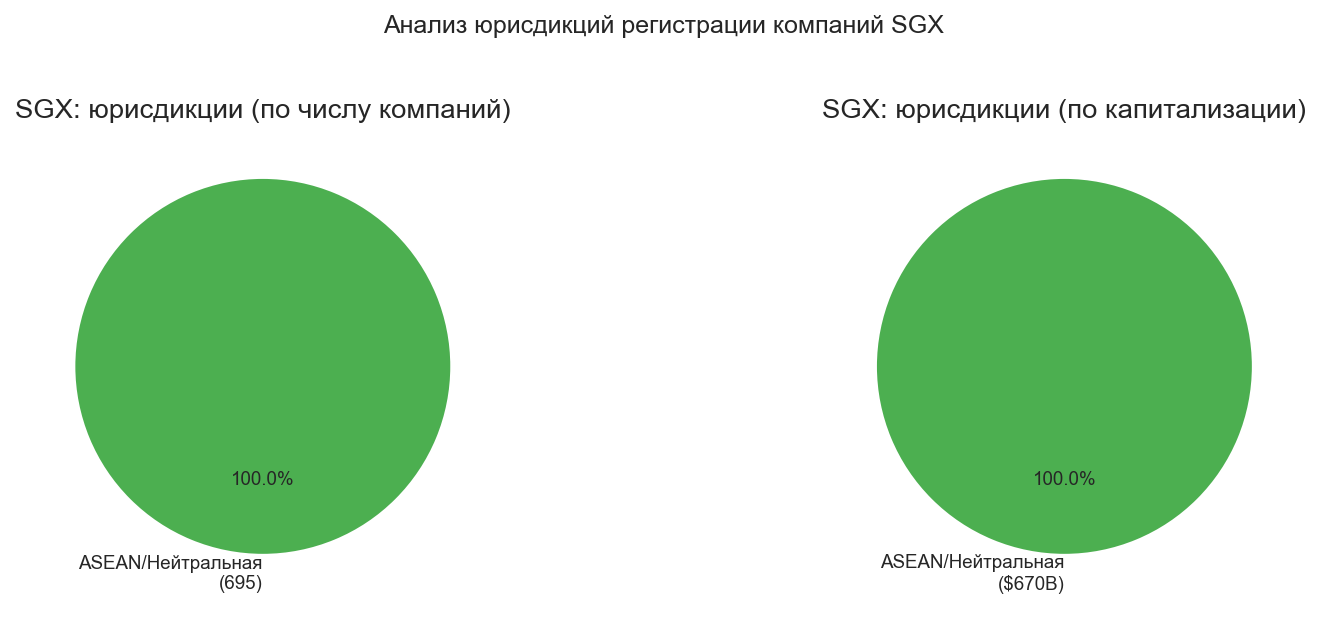

In [20]:
# --- SGX: анализ юрисдикций регистрации ---
df_sgx = df[df['Country'] == 'Singapore'].copy()
df_sgx['Incorporated in'] = df_sgx['Incorporated in'].fillna('Unknown').str.strip()

juris = df_sgx['Incorporated in'].value_counts()
print(f'SGX: {len(df_sgx)} компаний, юрисдикции регистрации:\n')
display(juris.head(15))

# Классификация юрисдикций
offshore = ['Cayman Islands', 'British Virgin Islands', 'Bermuda', 'Jersey', 'Isle of Man',
            'Guernsey', 'Cyprus', 'Mauritius']
unfriendly = ['United Kingdom', 'Australia', 'Japan', 'United States']

df_sgx['Jurisdiction_Type'] = 'ASEAN/Нейтральная'
df_sgx.loc[df_sgx['Incorporated in'].isin(offshore), 'Jurisdiction_Type'] = 'Офшор'
df_sgx.loc[df_sgx['Incorporated in'].isin(unfriendly), 'Jurisdiction_Type'] = 'Недружественная'

jtype_stats = df_sgx.groupby('Jurisdiction_Type').agg(
    N=('Ticker', 'count'),
    MCap_USD=('MCap_USD_B', 'sum'),
).sort_values('N', ascending=False)
jtype_stats['Доля_N'] = (jtype_stats['N'] / jtype_stats['N'].sum() * 100).round(1)
jtype_stats['Доля_MCap'] = (jtype_stats['MCap_USD'] / jtype_stats['MCap_USD'].sum() * 100).round(1)
jtype_stats.columns = ['Компаний', 'Капитализация ($B)', 'Доля (%)', 'Доля кап. (%)']
print('\nКлассификация юрисдикций SGX:')
display(jtype_stats)

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
jcolors = {'ASEAN/Нейтральная': '#4CAF50', 'Офшор': '#FF9800', 'Недружественная': '#E91E63'}

# Pie: по числу компаний
labels_j = jtype_stats.index.tolist()
sizes_j = jtype_stats['Компаний'].values
colors_j = [jcolors.get(l, 'gray') for l in labels_j]
ax1.pie(sizes_j, labels=[f'{l}\n({s})' for l, s in zip(labels_j, sizes_j)],
        colors=colors_j, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9})
ax1.set_title('SGX: юрисдикции (по числу компаний)')

# Pie: по капитализации
sizes_m = jtype_stats['Капитализация ($B)'].values
ax2.pie(sizes_m, labels=[f'{l}\n(${s:.0f}B)' for l, s in zip(labels_j, sizes_m)],
        colors=colors_j, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9})
ax2.set_title('SGX: юрисдикции (по капитализации)')

plt.suptitle('Анализ юрисдикций регистрации компаний SGX', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '12_sgx_jurisdictions.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Блок 10. Вьетнам — анализ по площадкам (HOSE / HNX / UPCOM)

Вьетнам: площадки листинга


,Компаний,С ценой,С кап.,Капитализация,Медиана MCap,Секторов
Market_Tier,,,,,,
Main,403,392,403,$178.6B,$41.6M,13
OTC,842,802,838,$32.7B,$4.2M,14
Secondary,302,300,302,$10.1B,$6.3M,14


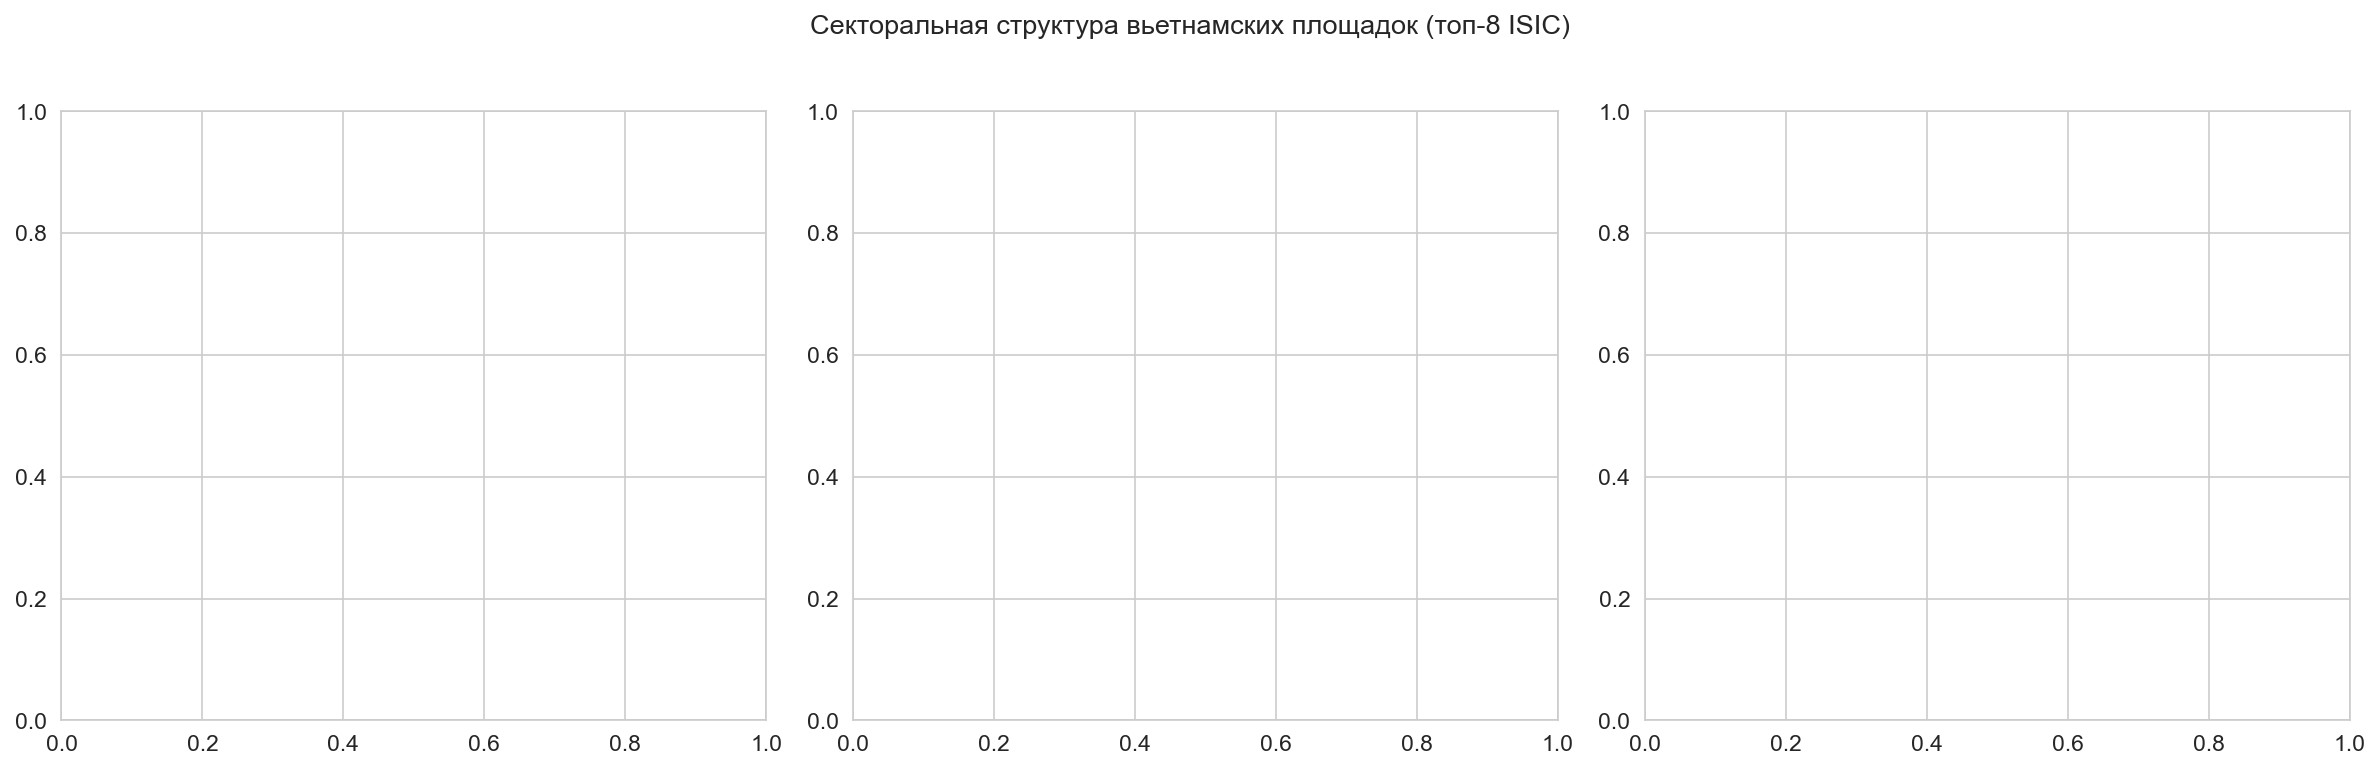

In [21]:
# --- Вьетнам: сравнение площадок HOSE / HNX / UPCOM ---
df_vn = df[df['Country'] == 'Vietnam'].copy()
df_vn['Market_Tier'] = df_vn['Market_Tier'].fillna('Unknown')

vn_tiers = df_vn.groupby('Market_Tier').agg(
    N=('Ticker', 'count'),
    С_ценой=('has_price', 'sum'),
    С_капитализацией=('has_mcap', 'sum'),
    Капитализация_USD_B=('MCap_USD_B', 'sum'),
    Медиана_MCap_M=('MCap_USD_B', lambda x: x[x > 0].median() * 1000 if (x > 0).any() else 0),
    Секторов=('ISIC_Section', lambda x: x.dropna().nunique()),
).sort_values('Капитализация_USD_B', ascending=False)

vn_tiers['Капитализация_USD_B'] = vn_tiers['Капитализация_USD_B'].apply(lambda x: f'${x:,.1f}B')
vn_tiers['Медиана_MCap_M'] = vn_tiers['Медиана_MCap_M'].apply(lambda x: f'${x:,.1f}M')
vn_tiers.columns = ['Компаний', 'С ценой', 'С кап.', 'Капитализация', 'Медиана MCap', 'Секторов']

print('Вьетнам: площадки листинга')
display(vn_tiers)

# Секторальная структура по площадкам
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, tier in enumerate(['HOSE', 'HNX', 'UPCOM']):
    tier_df = df_vn[(df_vn['Market_Tier'] == tier) & df_vn['has_isic']]
    if len(tier_df) == 0:
        continue
    sector_counts = tier_df['ISIC_Section'].value_counts().head(8)
    sector_counts.plot(kind='barh', ax=axes[i], color=plt.cm.Paired(np.linspace(0, 1, 8)),
                       edgecolor='white')
    axes[i].set_title(f'{tier} ({len(tier_df)} компаний)')
    axes[i].set_xlabel('Количество')
    axes[i].grid(axis='x', alpha=0.3)

plt.suptitle('Секторальная структура вьетнамских площадок (топ-8 ISIC)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '13_vietnam_tiers.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Блок 11. Топ-20 компаний АСЕАН и Таиланд (SET)

Топ-20 крупнейших публичных компаний АСЕАН:


,№,Компания,Биржа,Страна,ISIC,Капитализация
0,1,DBS GROUP HOLDINGS LTD,SGX,Сингапур,K,$121.3B
1,2,DELTA ELECTRONICS (THAILAND) PUBLIC COMPANY LI...,SET,Таиланд,J,$98.0B
2,3,OVERSEA-CHINESE BANKING CORPORATION LIMITED,SGX,Сингапур,K,$71.3B
3,4,SINGAPORE TELECOMMUNICATIONS LIMITED,SGX,Сингапур,J,$62.6B
4,5,PT Bank Central Asia Tbk.,IDX,Индонезия,K,$52.1B
5,6,PT Barito Renewables Energy Tbk.,IDX,Индонезия,D,$48.5B
6,7,UNITED OVERSEAS BANK LIMITED,SGX,Сингапур,K,$45.7B
7,8,PT Bank Rakyat Indonesia (Persero) Tbk,IDX,Индонезия,K,$33.0B
8,9,ADVANCED INFO SERVICE PUBLIC COMPANY LIMITED,SET,Таиланд,J,$32.3B
9,10,Malayan Banking Berhad,Bursa Malaysia,Малайзия,K,$31.5B


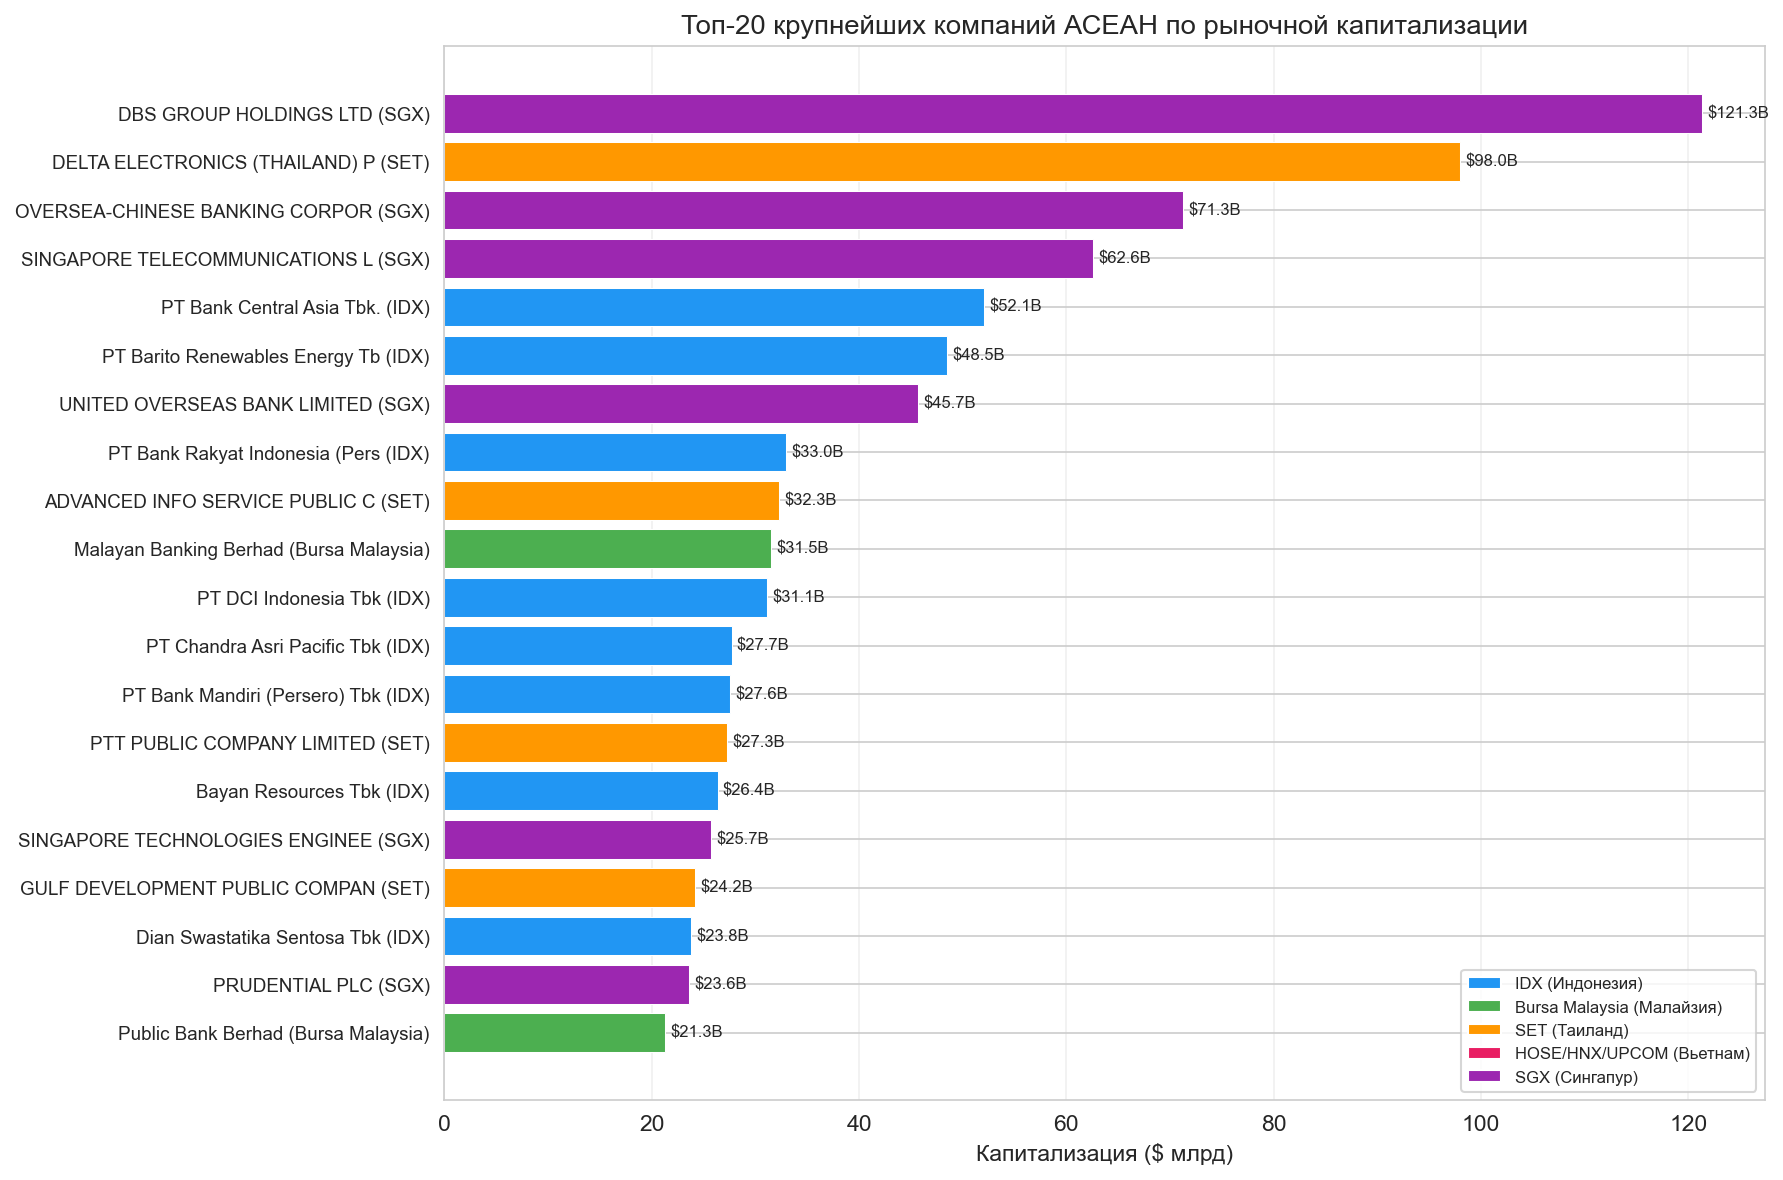

In [22]:
# --- Топ-20 крупнейших компаний АСЕАН ---
top20 = df[df['MCap_USD_B'] > 0].nlargest(20, 'MCap_USD_B')[[
    'Full Company Name', 'Exchange_Name', 'Country_RU', 'ISIC_Section', 'MCap_USD_B'
]].copy()
top20.insert(0, '№', range(1, 21))
top20['MCap_USD_B'] = top20['MCap_USD_B'].apply(lambda x: f'${x:,.1f}B')
top20['ISIC_Section'] = top20['ISIC_Section'].fillna('—')
top20.columns = ['№', 'Компания', 'Биржа', 'Страна', 'ISIC', 'Капитализация']

print('Топ-20 крупнейших публичных компаний АСЕАН:')
display(top20.reset_index(drop=True))

# Визуализация: горизонтальный бар-чарт
fig, ax = plt.subplots(figsize=(12, 8))
top20_plot = df[df['MCap_USD_B'] > 0].nlargest(20, 'MCap_USD_B').copy()
top20_plot['Label'] = top20_plot.apply(
    lambda r: f'{(r["Full Company Name"] or "?")[:30]} ({r["Exchange_Name"]})', axis=1)
color_map = {c: colors_country[i] for i, c in enumerate(COUNTRIES)}
bar_colors = [color_map.get(r['Country'], 'gray') for _, r in top20_plot.iterrows()]

bars = ax.barh(range(len(top20_plot)), top20_plot['MCap_USD_B'].values,
               color=bar_colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(top20_plot)))
ax.set_yticklabels(top20_plot['Label'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Капитализация ($ млрд)')
ax.set_title('Топ-20 крупнейших компаний АСЕАН по рыночной капитализации')
ax.grid(axis='x', alpha=0.3)

# Легенда по странам
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=colors_country[i], label=f'{EXCHANGE[c]} ({COUNTRY_RU[c]})')
              for i, c in enumerate(COUNTRIES)]
ax.legend(handles=legend_els, fontsize=8, loc='lower right')

for bar, val in zip(bars, top20_plot['MCap_USD_B'].values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'${val:.1f}B', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '14_top20_companies.png'), dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# --- Таиланд (SET): секторальный профиль ---
df_th = df[(df['Country'] == 'Thailand') & (df['Market_Cap'] > 0) & df['has_isic']].copy()

th_sectors = df_th.groupby('ISIC_Section').agg(
    N=('Ticker', 'count'),
    MCap_USD=('MCap_USD_B', 'sum'),
    Медиана_MCap=('MCap_USD_B', 'median'),
).sort_values('MCap_USD', ascending=False)

th_sectors['Доля_N'] = (th_sectors['N'] / th_sectors['N'].sum() * 100).round(1)
th_sectors['Доля_MCap'] = (th_sectors['MCap_USD'] / th_sectors['MCap_USD'].sum() * 100).round(1)
th_sectors.index = th_sectors.index.map(lambda x: f'{x} — {ISIC_NAMES.get(x, x)[:25]}')
th_sectors.columns = ['Компаний', 'Кап. ($B)', 'Мед. кап. ($B)', 'Доля N (%)', 'Доля кап. (%)']

print(f'SET (Таиланд): {len(df_th)} компаний, ${df_th["MCap_USD_B"].sum():,.0f}B')
print()
display(th_sectors)

# Топ-10 компаний SET
top10_th = df_th.nlargest(10, 'MCap_USD_B')[
    ['Full Company Name', 'ISIC_Section', 'Sector', 'MCap_USD_B']].copy()
top10_th.insert(0, '№', range(1, 11))
top10_th['MCap_USD_B'] = top10_th['MCap_USD_B'].apply(lambda x: f'${x:,.1f}B')
top10_th.columns = ['№', 'Компания', 'ISIC', 'Сектор', 'Капитализация']
print('\nТоп-10 компаний SET:')
display(top10_th.reset_index(drop=True))

SET (Таиланд): 857 компаний, $517B



,Компаний,Кап. ($B),Мед. кап. ($B),Доля N (%),Доля кап. (%)
ISIC_Section,,,,,
J — Информация и связь,97,155.622400,0.039572,11.3,30.1
D — Электро-/газоснабжение,59,95.618327,0.122028,6.9,18.5
K — Финансы и страхование,82,87.100934,0.089536,9.6,16.8
L — Операции с недвижимостью,209,43.934222,0.034043,24.4,8.5
H — Транспорт и хранение,33,33.207469,0.087392,3.9,6.4
G — Торговля опт./розн.,34,32.408073,0.157943,4.0,6.3
A — Сельское хозяйство,87,23.666481,0.088635,10.2,4.6
Q — Здравоохранение,36,18.127671,0.108950,4.2,3.5
C — Обрабатывающая промышленн,113,16.245347,0.034748,13.2,3.1



Топ-10 компаний SET:


,№,Компания,ISIC,Сектор,Капитализация
0,1,DELTA ELECTRONICS (THAILAND) PUBLIC COMPANY LI...,J,ETRON,$98.0B
1,2,ADVANCED INFO SERVICE PUBLIC COMPANY LIMITED,J,ICT,$32.3B
2,3,PTT PUBLIC COMPANY LIMITED,D,ENERG,$27.3B
3,4,GULF DEVELOPMENT PUBLIC COMPANY LIMITED,D,ENERG,$24.2B
4,5,AIRPORTS OF THAILAND PUBLIC COMPANY LIMITED,H,TRANS,$20.2B
5,6,PTT EXPLORATION AND PRODUCTION PUBLIC COMPANY ...,D,ENERG,$16.7B
6,7,SCB X PUBLIC COMPANY LIMITED,K,BANK,$14.0B
7,8,TRUE CORPORATION PUBLIC COMPANY LIMITED,J,ICT,$13.8B
8,9,KRUNG THAI BANK PUBLIC COMPANY LIMITED,K,BANK,$13.7B
9,10,KASIKORNBANK PUBLIC COMPANY LIMITED,K,BANK,$12.9B


---
## Блок 12. Сводная heatmap и экспорт результатов

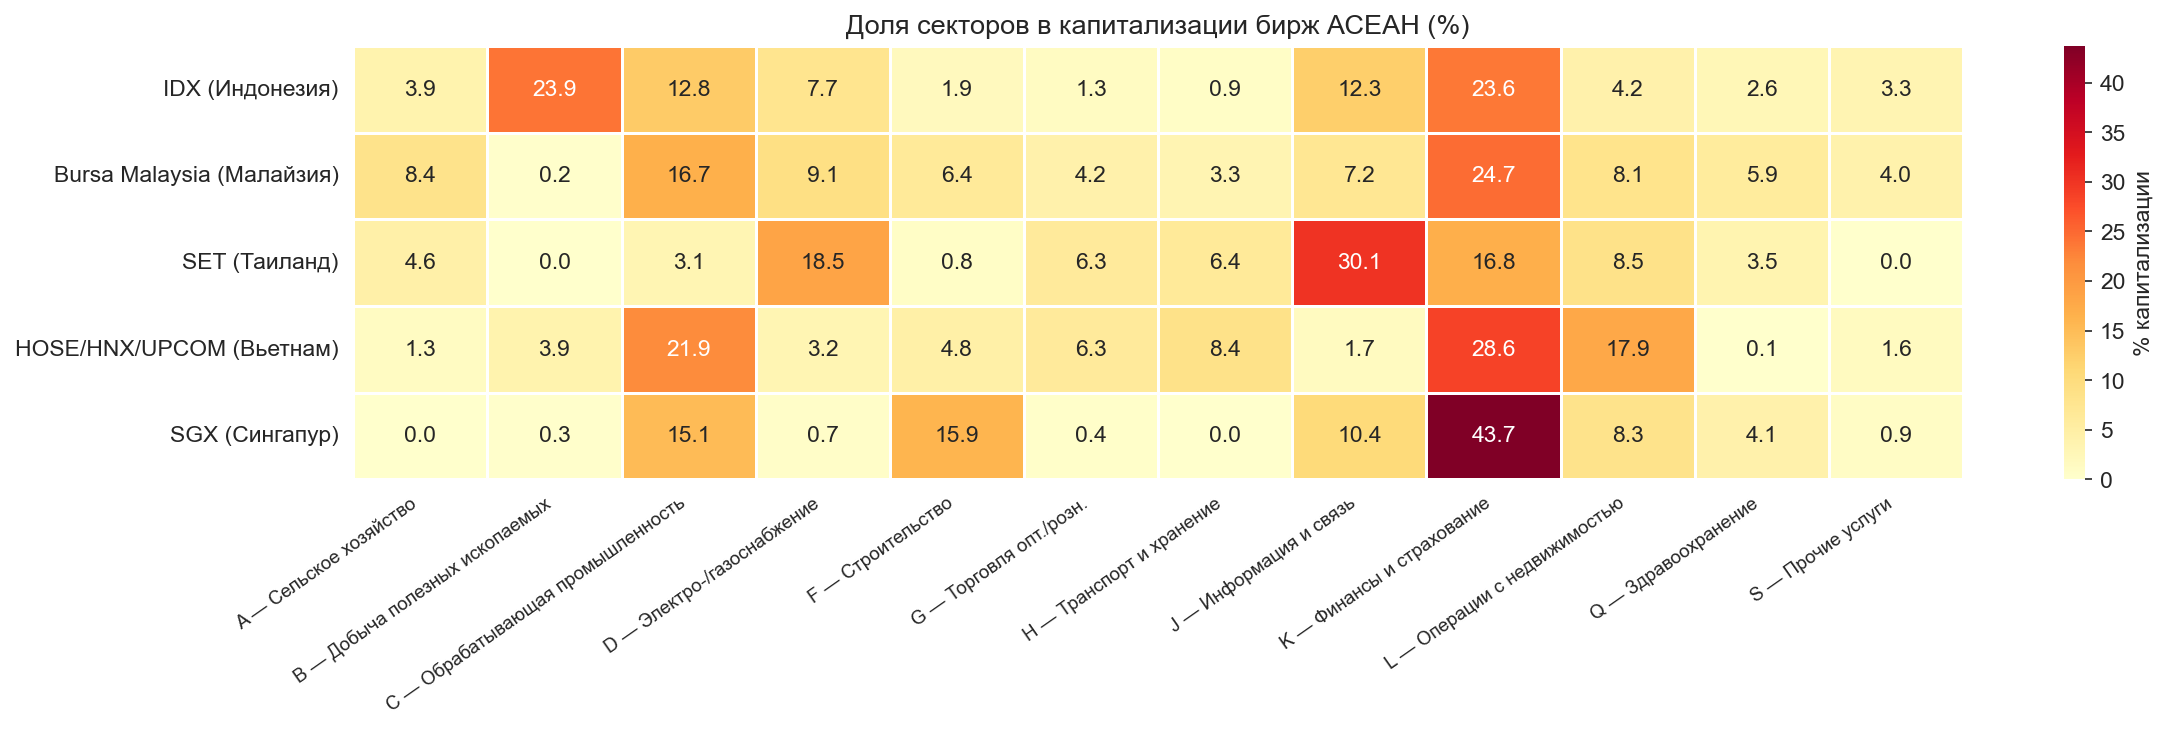

In [24]:
# --- Heatmap: доля секторов по капитализации (ISIC × страна) ---
mcap_matrix = df_isic.groupby(['Country', 'ISIC_Section'])['MCap_USD_B'].sum().unstack(fill_value=0)
mcap_matrix = mcap_matrix.reindex(COUNTRIES)
# Нормализация: доля сектора в каждой стране
mcap_pct_hm = mcap_matrix.div(mcap_matrix.sum(axis=1), axis=0) * 100

# Выбираем секторы с суммарной долей > 1%
cols_keep = mcap_pct_hm.columns[mcap_pct_hm.sum() > 5]
mcap_pct_hm = mcap_pct_hm[cols_keep]
mcap_pct_hm.index = [f'{EXCHANGE[c]} ({COUNTRY_RU[c]})' for c in COUNTRIES]
mcap_pct_hm.columns = [f'{s} — {ISIC_NAMES.get(s, s)}' for s in mcap_pct_hm.columns]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(mcap_pct_hm, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': '% капитализации'})
ax.set_title('Доля секторов в капитализации бирж АСЕАН (%)', fontsize=13)
ax.set_ylabel('')
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '15_heatmap_sectors.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Блок 13. Маппинг HS-кодов на публичные компании АСЕАН

Сопоставление товарных групп из торговли Россия–Индонезия (UN Comtrade, HS2) с конкретными эмитентами фондовых бирж АСЕАН.

In [25]:
# --- Маппинг HS-кодов на компании IDX ---

# Загрузка полных данных IDX с текстовыми описаниями
with open(os.path.join(BASE_DIR, 'Indonesia', 'idx_classified.json'), 'r', encoding='utf-8') as f:
    idx_full = json.load(f)

df_idx_full = pd.DataFrame(idx_full)
df_idx_full['Market_Cap'] = pd.to_numeric(df_idx_full['Market_Cap'], errors='coerce').fillna(0)
df_idx_full['MCap_USD_B'] = df_idx_full['Market_Cap'] * FX['Indonesia'] / 1e9

# Подгружаем финансовые данные
with open(os.path.join(BASE_DIR, 'Indonesia', 'old', 'merged_companies_data.json'), 'r', encoding='utf-8') as f:
    idx_fin_raw = json.load(f)

idx_fin_df = pd.DataFrame(idx_fin_raw)[['Ticker', 'Revenue', 'Net_Income', 'Free_Cash_Flow', 'Revenue_Growth']].copy()
for col in ['Revenue', 'Net_Income', 'Free_Cash_Flow', 'Revenue_Growth']:
    idx_fin_df[col] = idx_fin_df[col].apply(parse_idr)

df_idx_full = df_idx_full.merge(idx_fin_df, on='Ticker', how='left')
df_idx_full['Profit_Margin'] = np.where(
    df_idx_full['Revenue'] > 0,
    df_idx_full['Net_Income'] / df_idx_full['Revenue'] * 100, np.nan)

# --- HS -> компании: правила маппинга ---
# На основе товарной структуры торговли Россия-Индонезия (Самандраков, UN Comtrade 2021-2025)
HS_COMPANY_MAP = {
    'HS 15 — Масла и жиры (пальмовое масло)': {
        'keywords': ['sawit', 'kelapa sawit', 'palm oil', 'cpo '],
        'fields': ['Main Business Fields', 'Full Company Name', 'DESCRIPTION'],
        'share_export': 59.4, 'rca': 55.41,
    },
    'HS 40 — Каучук и резина': {
        'keywords': ['karet', 'rubber', 'ban ', 'tire', 'tyre'],
        'fields': ['Main Business Fields', 'Full Company Name', 'Industry', 'Sub-industry'],
        'share_export': 13.2, 'rca': 2.87,
    },
    'HS 18 — Какао': {
        'keywords': ['kakao', 'cocoa', 'cokelat', 'chocolate'],
        'fields': ['Main Business Fields', 'Full Company Name'],
        'share_export': 3.8, 'rca': 3.72,
    },
    'HS 09 — Кофе и специи': {
        'keywords': ['kopi', 'coffee', 'rempah', 'lada', 'pepper'],
        'fields': ['Main Business Fields', 'Full Company Name'],
        'share_export': 3.2, 'rca': 4.49,
    },
    'HS 80 — Олово': {
        'keywords': ['timah', 'tin ', 'solder'],
        'fields': ['Main Business Fields', 'Full Company Name', 'Sub-industry'],
        'share_export': 1.5, 'rca': 13.53,
    },
    'HS 27 — Нефть, газ, уголь': {
        'keywords': ['batu bara', 'coal', 'minyak bumi', 'petroleum', 'lng ', 'natural gas'],
        'fields': ['Main Business Fields', 'Full Company Name', 'Industry', 'Sub-industry'],
        'share_import': 38.1, 'rca': None,
    },
    'HS 31 — Удобрения': {
        'keywords': ['pupuk', 'fertilizer', 'urea', 'amoniak', 'ammonia'],
        'fields': ['Main Business Fields', 'Full Company Name', 'Industry'],
        'share_import': 23.5, 'rca': None,
    },
    'HS 72 — Чёрные металлы': {
        'keywords': ['baja', 'besi', 'steel', 'iron', 'krakatau'],
        'fields': ['Main Business Fields', 'Full Company Name', 'Sub-industry'],
        'share_import': 20.2, 'rca': None,
    },
    'HS 75 — Никель': {
        'keywords': ['nikel', 'nickel', 'laterit', 'ferronickel'],
        'fields': ['Main Business Fields', 'Full Company Name', 'DESCRIPTION'],
        'share_export': 2.0, 'rca': 8.2,
    },
}

def match_companies(df, keywords, fields):
    mask = pd.Series(False, index=df.index)
    for field in fields:
        if field not in df.columns:
            continue
        for kw in keywords:
            mask |= df[field].fillna('').str.lower().str.contains(kw, regex=False)
    return mask

# Маппинг
hs_results = []
hs_company_lists = {}
for hs_name, config in HS_COMPANY_MAP.items():
    mask = match_companies(df_idx_full, config['keywords'], config['fields'])
    matched = df_idx_full[mask].copy()
    hs_company_lists[hs_name] = matched
    total_mcap = matched['MCap_USD_B'].sum()
    total_rev = matched['Revenue'].sum() / 1e12 if matched['Revenue'].notna().any() else 0
    direction = 'Экспорт ИДН→РФ' if 'share_export' in config else 'Импорт ИДН←РФ'
    share = config.get('share_export', config.get('share_import', 0))
    rca = config.get('rca')
    hs_parts = hs_name.split(' — ')
    hs_results.append({
        'HS-группа': hs_parts[0],
        'Товар': hs_parts[1] if len(hs_parts) > 1 else hs_name,
        'Направление': direction,
        'Доля в торговле (%)': share,
        'RCA': rca if rca else '—',
        'Компаний IDX': len(matched),
        'Капитализация ($B)': round(total_mcap, 1),
    })

hs_df = pd.DataFrame(hs_results)
print('Маппинг HS-кодов на публичные компании IDX:')
print('(UN Comtrade 2021-2025, Самандраков)')
print()
display(hs_df)

Маппинг HS-кодов на публичные компании IDX:
(UN Comtrade 2021-2025, Самандраков)



,HS-группа,Товар,Направление,Доля в торговле (%),RCA,Компаний IDX,Капитализация ($B)
0,HS 15,Масла и жиры (пальмовое масло),Экспорт ИДН→РФ,59.4,55.41,29,21.9
1,HS 40,Каучук и резина,Экспорт ИДН→РФ,13.2,2.87,12,7.2
2,HS 18,Какао,Экспорт ИДН→РФ,3.8,3.72,2,0.1
3,HS 09,Кофе и специи,Экспорт ИДН→РФ,3.2,4.49,5,3.5
4,HS 80,Олово,Экспорт ИДН→РФ,1.5,13.53,3,1.6
5,HS 27,"Нефть, газ, уголь",Импорт ИДН←РФ,38.1,—,72,105.7
6,HS 31,Удобрения,Импорт ИДН←РФ,23.5,—,5,0.5
7,HS 72,Чёрные металлы,Импорт ИДН←РФ,20.2,—,15,3.1
8,HS 75,Никель,Экспорт ИДН→РФ,2.0,8.2,9,19.2


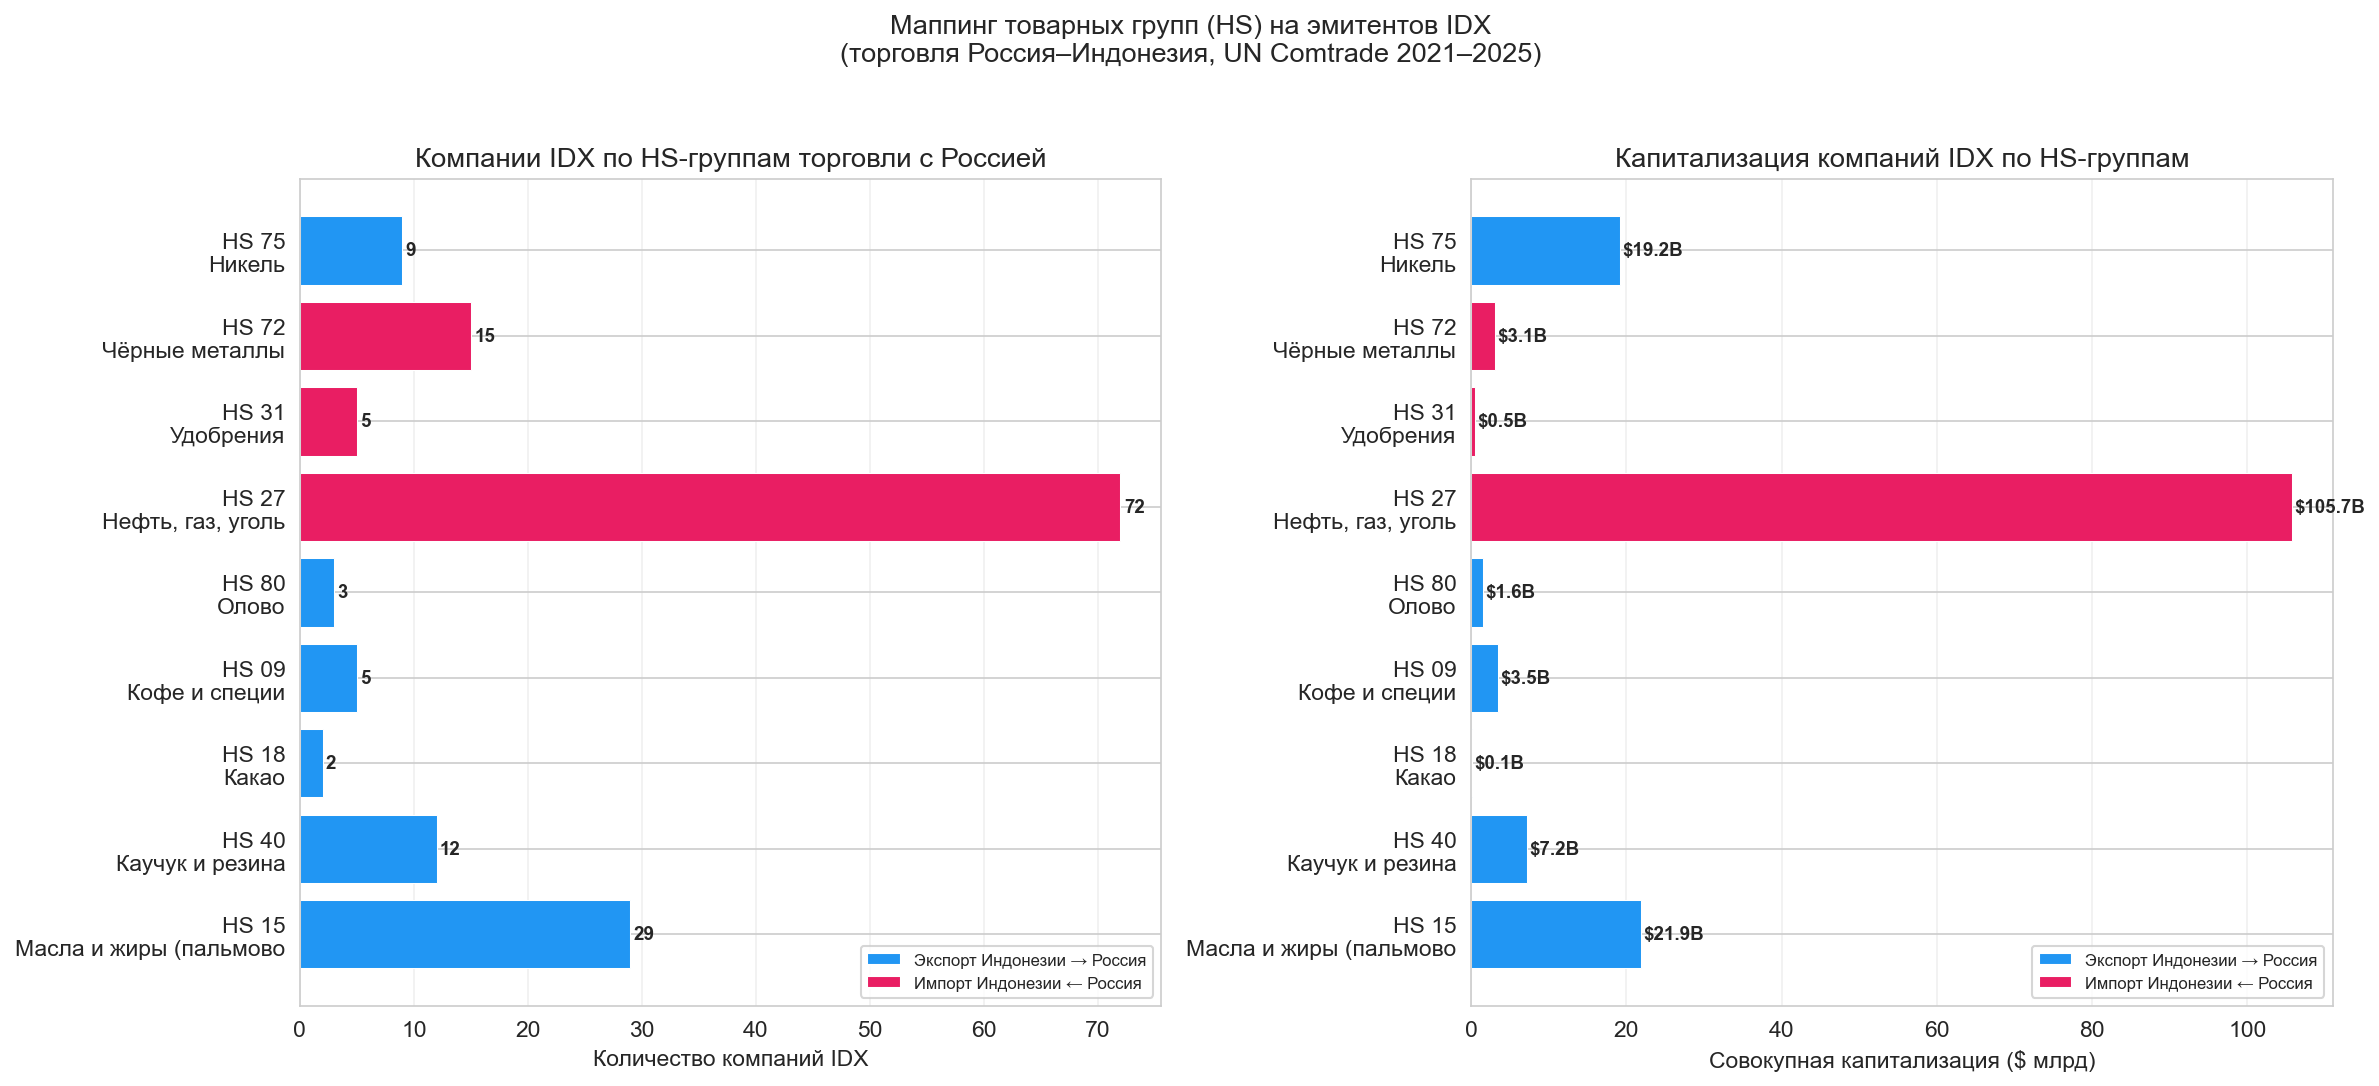

In [26]:
# --- Визуализация: HS-группы -> компании IDX ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

hs_labels = [r['HS-группа'] + '\n' + str(r['Товар'])[:22] for _, r in hs_df.iterrows()]
n_companies = hs_df['Компаний IDX'].values
mcap_values = hs_df['Капитализация ($B)'].values
bar_colors = ['#2196F3' if '→' in str(d) else '#E91E63' for d in hs_df['Направление']]

bars1 = ax1.barh(hs_labels, n_companies, color=bar_colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars1, n_companies):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             str(int(val)), va='center', fontsize=9, fontweight='bold')
ax1.set_xlabel('Количество компаний IDX')
ax1.set_title('Компании IDX по HS-группам торговли с Россией')
ax1.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
leg = [Patch(facecolor='#2196F3', label='Экспорт Индонезии → Россия'),
       Patch(facecolor='#E91E63', label='Импорт Индонезии ← Россия')]
ax1.legend(handles=leg, fontsize=8, loc='lower right')

bars2 = ax2.barh(hs_labels, mcap_values, color=bar_colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars2, mcap_values):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'${val:.1f}B', va='center', fontsize=9, fontweight='bold')
ax2.set_xlabel('Совокупная капитализация ($ млрд)')
ax2.set_title('Капитализация компаний IDX по HS-группам')
ax2.grid(axis='x', alpha=0.3)
ax2.legend(handles=leg, fontsize=8, loc='lower right')

plt.suptitle('Маппинг товарных групп (HS) на эмитентов IDX\n(торговля Россия–Индонезия, UN Comtrade 2021–2025)',
             fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '16_hs_company_mapping.png'), dpi=150, bbox_inches='tight')
plt.show()

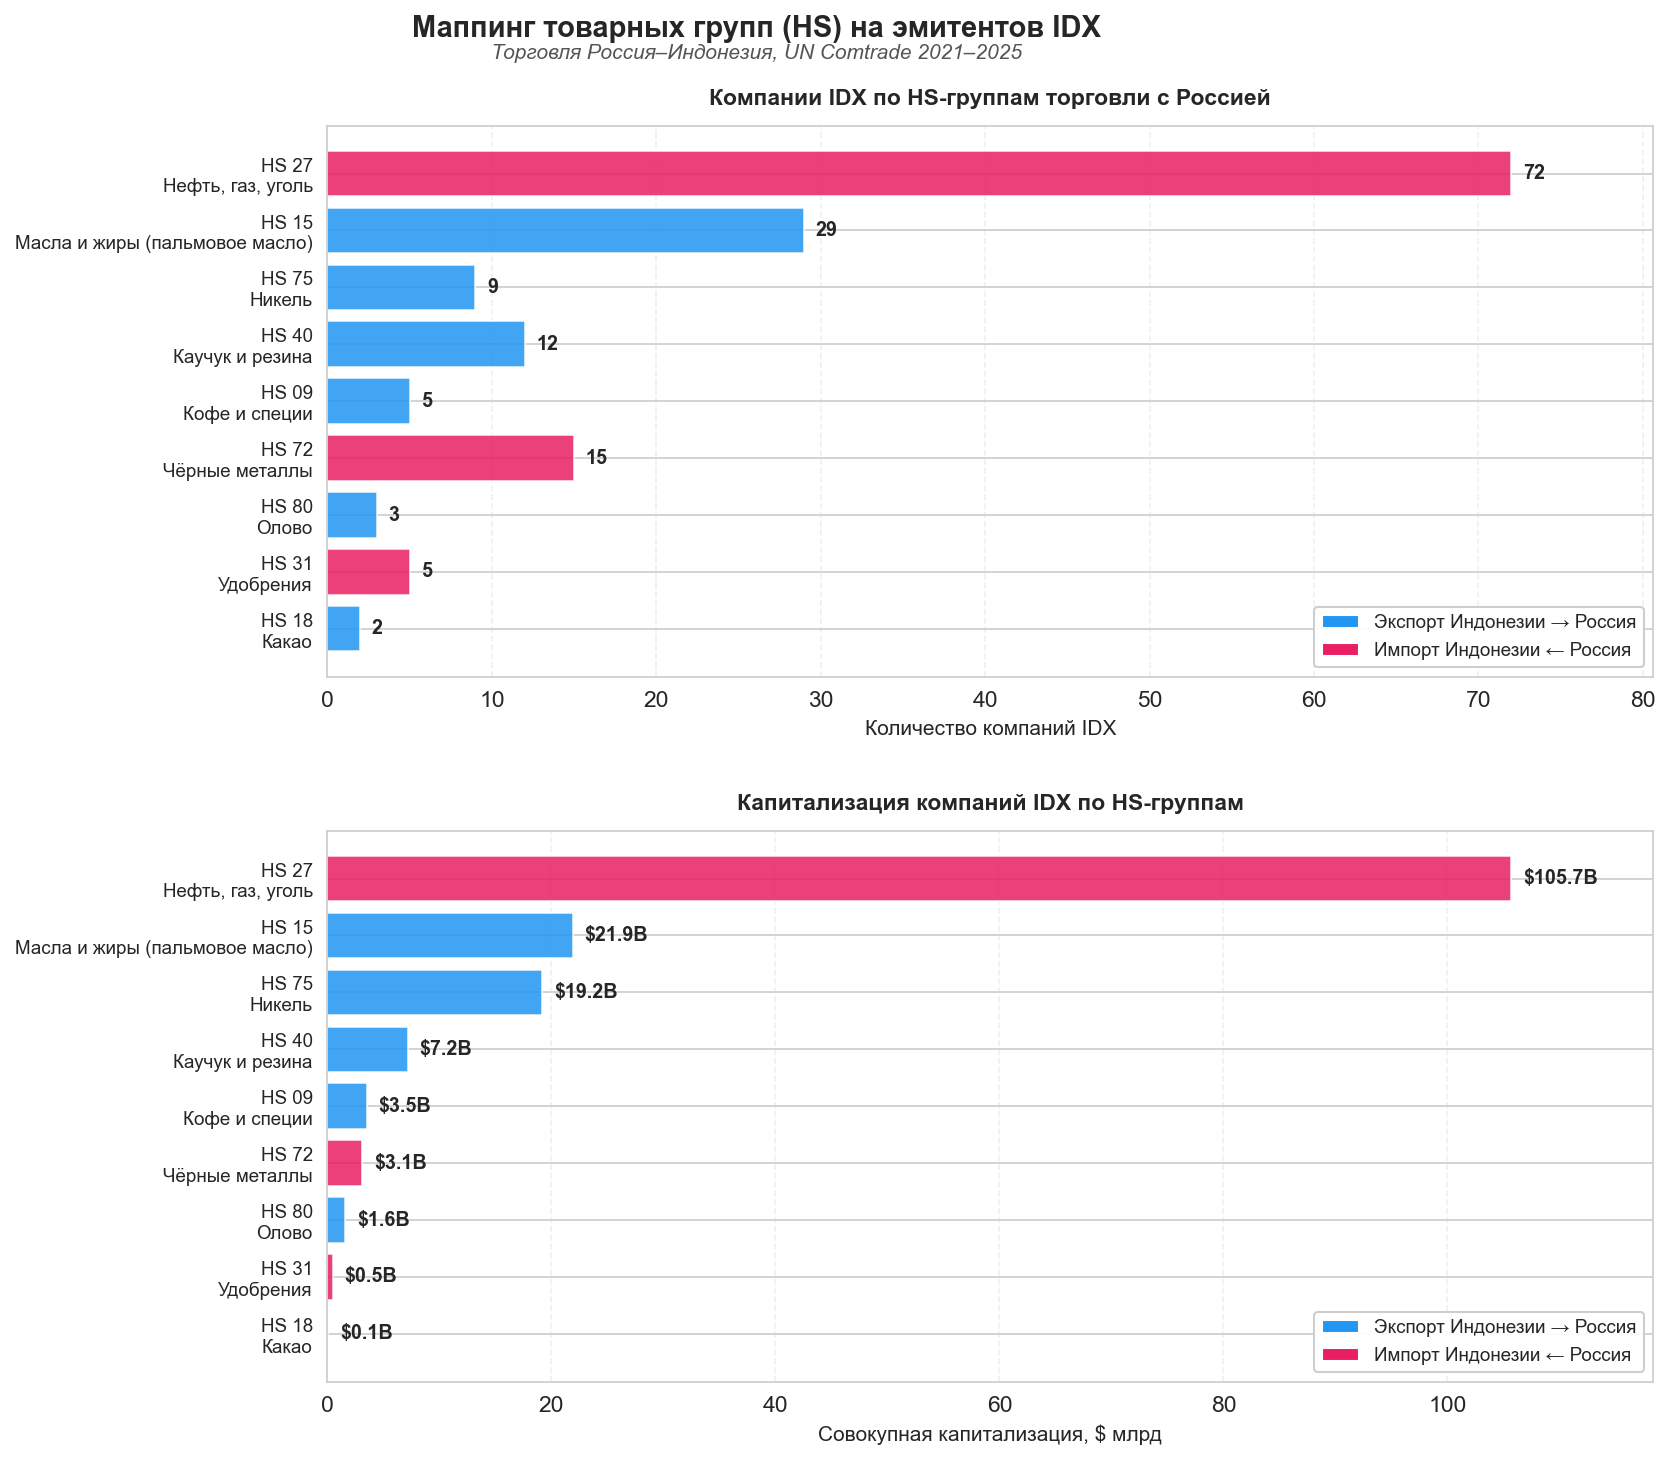

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

hs_df_sorted = hs_df.sort_values('Капитализация ($B)', ascending=True).reset_index(drop=True)

def make_label(row):
    hs_code = row['HS-группа']
    tovar = str(row['Товар'])
    tovar_short = tovar if len(tovar) <= 45 else tovar[:43] + '…'
    return f'{hs_code}\n{tovar_short}'

hs_labels = [make_label(r) for _, r in hs_df_sorted.iterrows()]
n_companies = hs_df_sorted['Компаний IDX'].values
mcap_values = hs_df_sorted['Капитализация ($B)'].values

EXPORT_COLOR = '#2196F3'
IMPORT_COLOR = '#E91E63'
bar_colors = [EXPORT_COLOR if '→' in str(d) else IMPORT_COLOR 
              for d in hs_df_sorted['Направление']]

n_groups = len(hs_df_sorted)
fig_height = max(9, n_groups * 0.65 + 4)  # +4 вместо +3.5 — больше места сверху

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, fig_height),
                                gridspec_kw={'hspace': 0.28})

# top=0.90 вместо 0.93 — резервируем больше места под двухстрочную шапку
plt.subplots_adjust(left=0.28, right=0.96, top=0.90, bottom=0.05)

# ============ ВЕРХ ============
bars1 = ax1.barh(hs_labels, n_companies, color=bar_colors,
                 edgecolor='white', linewidth=0.8, alpha=0.85)
for bar, val in zip(bars1, n_companies):
    ax1.text(bar.get_width() + max(n_companies) * 0.01,
             bar.get_y() + bar.get_height()/2,
             str(int(val)), va='center', fontsize=9.5, fontweight='bold')

ax1.set_xlabel('Количество компаний IDX', fontsize=10)
ax1.set_title('Компании IDX по HS-группам торговли с Россией',
              fontsize=11, fontweight='bold', pad=10)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)
ax1.set_xlim(0, max(n_companies) * 1.12)
ax1.tick_params(axis='y', labelsize=9)

legend_items = [Patch(facecolor=EXPORT_COLOR, label='Экспорт Индонезии → Россия'),
                Patch(facecolor=IMPORT_COLOR, label='Импорт Индонезии ← Россия')]
ax1.legend(handles=legend_items, fontsize=9, loc='lower right', framealpha=0.95)

# ============ НИЗ ============
bars2 = ax2.barh(hs_labels, mcap_values, color=bar_colors,
                 edgecolor='white', linewidth=0.8, alpha=0.85)
for bar, val in zip(bars2, mcap_values):
    ax2.text(bar.get_width() + max(mcap_values) * 0.01,
             bar.get_y() + bar.get_height()/2,
             f'${val:.1f}B', va='center', fontsize=9.5, fontweight='bold')

ax2.set_xlabel('Совокупная капитализация, $ млрд', fontsize=10)
ax2.set_title('Капитализация компаний IDX по HS-группам',
              fontsize=11, fontweight='bold', pad=10)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)
ax2.set_xlim(0, max(mcap_values) * 1.12)
ax2.tick_params(axis='y', labelsize=9)
ax2.legend(handles=legend_items, fontsize=9, loc='lower right', framealpha=0.95)

# РАЗНОСИМ заголовок и подзаголовок по вертикали
fig.suptitle('Маппинг товарных групп (HS) на эмитентов IDX',
             fontsize=14, fontweight='bold', y=0.975)
fig.text(0.5, 0.945,                    # было 0.958, стало 0.945 — зазор больше
         'Торговля Россия–Индонезия, UN Comtrade 2021–2025',
         ha='center', fontsize=10, style='italic', color='#555')

plt.savefig(os.path.join(OUT_DIR, '16_hs_company_mapping.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [27]:
# --- Топ-компании по каждой HS-группе ---
for hs_name, matched in hs_company_lists.items():
    if len(matched) == 0:
        continue
    config = HS_COMPANY_MAP[hs_name]
    share = config.get('share_export', config.get('share_import', 0))
    rca = config.get('rca')
    direction = '→ РФ' if 'share_export' in config else '← РФ'
    rca_str = f', RCA = {rca}' if rca else ''
    print(f'\n{"=" * 80}')
    print(f'{hs_name}  |  {direction} {share}% торговли{rca_str}')
    print(f'{"=" * 80}')

    top = matched.nlargest(min(7, len(matched)), 'MCap_USD_B')[
        ['Ticker', 'Full Company Name', 'MCap_USD_B', 'Revenue', 'Profit_Margin']
    ].copy()
    top['Rev'] = top['Revenue'].apply(
        lambda x: f'{x/1e12:.1f}T' if pd.notna(x) and abs(x) >= 1e12
        else (f'{x/1e9:.0f}B' if pd.notna(x) and abs(x) >= 1e9 else '—'))
    top['Margin'] = top['Profit_Margin'].apply(
        lambda x: f'{x:.1f}%' if pd.notna(x) else '—')
    top['MCap'] = top['MCap_USD_B'].apply(lambda x: f'${x:.2f}B')
    out = top[['Ticker', 'Full Company Name', 'MCap', 'Rev', 'Margin']].copy()
    out.columns = ['Тикер', 'Компания', 'Капитализация', 'Выручка', 'Маржа']
    display(out.reset_index(drop=True))


HS 15 — Масла и жиры (пальмовое масло)  |  → РФ 59.4% торговли, RCA = 55.41


,Тикер,Компания,Капитализация,Выручка,Маржа
0,AADI,PT Adaro Andalan Indonesia Tbk,$5.11B,81.4T,14.8%
1,PGUN,PT Pradiksi Gunatama Tbk,$2.81B,889B,18.2%
2,TAPG,PT Triputra Agro Persada Tbk.,$2.17B,11.6T,35.9%
3,FAPA,PT FAP Agri Tbk,$1.43B,7.0T,14.1%
4,NSSS,PT Nusantara Sawit Sejahtera Tbk,$1.33B,2.0T,35.6%
5,JARR,PT Jhonlin Agro Raya Tbk,$1.05B,4.3T,7.6%
6,DSNG,PT Dharma Satya Nusantara Tbk.,$0.92B,11.9T,13.5%



HS 40 — Каучук и резина  |  → РФ 13.2% торговли, RCA = 2.87


,Тикер,Компания,Капитализация,Выручка,Маржа
0,AADI,PT Adaro Andalan Indonesia Tbk,$5.11B,81.4T,14.8%
1,JSMR,PT Jasa Marga Tbk,$1.41B,27.3T,14.5%
2,PNGO,PT Pinago Utama Tbk,$0.15B,2.3T,12.7%
3,JAWA,Jaya Agra Wattie Tbk,$0.15B,1.8T,1.4%
4,FPNI,PT Lotte Chemical Titan Tbk.,$0.13B,5.3T,0.1%
5,BRAM,Indo Kordsa Tbk,$0.12B,2.4T,-0.4%
6,URBN,PT Urban Jakarta Propertindo Tbk.,$0.03B,-17B,—



HS 18 — Какао  |  → РФ 3.8% торговли, RCA = 3.72


...

,Тикер,Компания,Капитализация,Выручка,Маржа
0,SAMF,PT Saraswanti Anugerah Makmur Tbk.,$0.22B,4.1T,6.6%
1,DGWG,PT Delta Giri Wacana Tbk,$0.13B,3.6T,5.2%
2,PSAT,PT Pancaran Samudera Transport Tbk,$0.08B,1.1T,10.8%
3,MOLI,PT Madusari Murni Indah Tbk.,$0.04B,1.4T,1.6%
4,NPGF,PT Nusa Palapa Gemilang Tbk,$0.01B,199B,1.8%



HS 72 — Чёрные металлы  |  ← РФ 20.2% торговли


,Тикер,Компания,Капитализация,Выручка,Маржа
0,VKTR,PT VKTR Teknologi Mobilitas Tbk,$1.85B,1.1T,-0.2%
1,KRAS,Krakatau Steel (Persero) Tbk,$0.34B,16.7T,5.3%
2,CTBN,Citra Tubindo Tbk,$0.29B,5.1T,9.6%
3,GGRP,PT Gunung Raja Paksi Tbk.,$0.22B,3.8T,-7.2%
4,ISSP,PT Steel Pipe Industry of Indonesia Tbk,$0.21B,6.0T,9.1%
5,PSAT,PT Pancaran Samudera Transport Tbk,$0.08B,1.1T,10.8%
6,GDST,Gunawan Dianjaya Steel Tbk,$0.06B,2.3T,4.4%



HS 75 — Никель  |  → РФ 2.0% торговли, RCA = 8.2


,Тикер,Компания,Капитализация,Выручка,Маржа
0,MDKA,PT Merdeka Copper Gold Tbk.,$5.05B,32.5T,-3.0%
1,MBMA,PT Merdeka Battery Materials Tbk,$4.72B,25.2T,0.5%
2,NCKL,PT Trimegah Bangun Persada Tbk.,$4.51B,29.0T,27.6%
3,INCO,Vale Indonesia Tbk,$3.67B,15.8T,6.2%
4,NICL,PT PAM Mineral Tbk,$0.58B,2.0T,27.7%
5,IFSH,PT Ifishdeco Tbk.,$0.39B,932B,6.7%
6,NICE,PT Adhi Kartiko Pratama Tbk,$0.11B,1.0T,13.7%


---
## Блок 14. RCA-взвешенный анализ компаний IDX

Финансовое здоровье компаний в секторах с высоким выявленным сравнительным преимуществом (RCA) Индонезии.

In [28]:
# --- RCA-взвешенный агрегат ---
rca_groups = {k: v for k, v in HS_COMPANY_MAP.items() if v.get('rca') and v['rca'] > 1}

rca_agg = []
for hs_name, config in rca_groups.items():
    matched = hs_company_lists[hs_name]
    if len(matched) == 0:
        continue
    rca = config['rca']
    share = config.get('share_export', 0)
    has_fin = matched[matched['Revenue'] > 0]
    rca_agg.append({
        'HS-группа': hs_name,
        'RCA': rca,
        'Доля в экспорте (%)': share,
        'Компаний': len(matched),
        'С выручкой': len(has_fin),
        'Капитализация ($B)': matched['MCap_USD_B'].sum(),
        'Мед. маржа (%)': has_fin['Profit_Margin'].median() if len(has_fin) > 0 else np.nan,
        'Доля прибыльных (%)': (has_fin['Net_Income'] > 0).mean() * 100 if len(has_fin) > 0 else np.nan,
    })

rca_agg_df = pd.DataFrame(rca_agg).sort_values('RCA', ascending=False)
rca_fmt = rca_agg_df.copy()
rca_fmt['Капитализация ($B)'] = rca_fmt['Капитализация ($B)'].apply(lambda x: f'${x:,.1f}B')
rca_fmt['Мед. маржа (%)'] = rca_fmt['Мед. маржа (%)'].apply(lambda x: f'{x:.1f}%' if pd.notna(x) else '-')
rca_fmt['Доля прибыльных (%)'] = rca_fmt['Доля прибыльных (%)'].apply(lambda x: f'{x:.0f}%' if pd.notna(x) else '-')

print('RCA-взвешенный профиль секторов IDX (экспорт Индонезии → Россия):')
print('(RCA > 1 = выявленное сравнительное преимущество, Баласса)')
print()
display(rca_fmt)

RCA-взвешенный профиль секторов IDX (экспорт Индонезии → Россия):
(RCA > 1 = выявленное сравнительное преимущество, Баласса)



,HS-группа,RCA,Доля в экспорте (%),Компаний,С выручкой,Капитализация ($B),Мед. маржа (%),Доля прибыльных (%)
0,HS 15 — Масла и жиры (пальмовое масло),55.41,59.4,29,26,$21.9B,12.5%,100%
4,HS 80 — Олово,13.53,1.5,3,3,$1.6B,9.6%,100%
5,HS 75 — Никель,8.20,2.0,9,9,$19.2B,6.7%,89%
3,HS 09 — Кофе и специи,4.49,3.2,5,5,$3.5B,7.5%,100%
2,HS 18 — Какао,3.72,3.8,2,2,$0.1B,-187.0%,0%
1,HS 40 — Каучук и резина,2.87,13.2,12,10,$7.2B,1.8%,70%


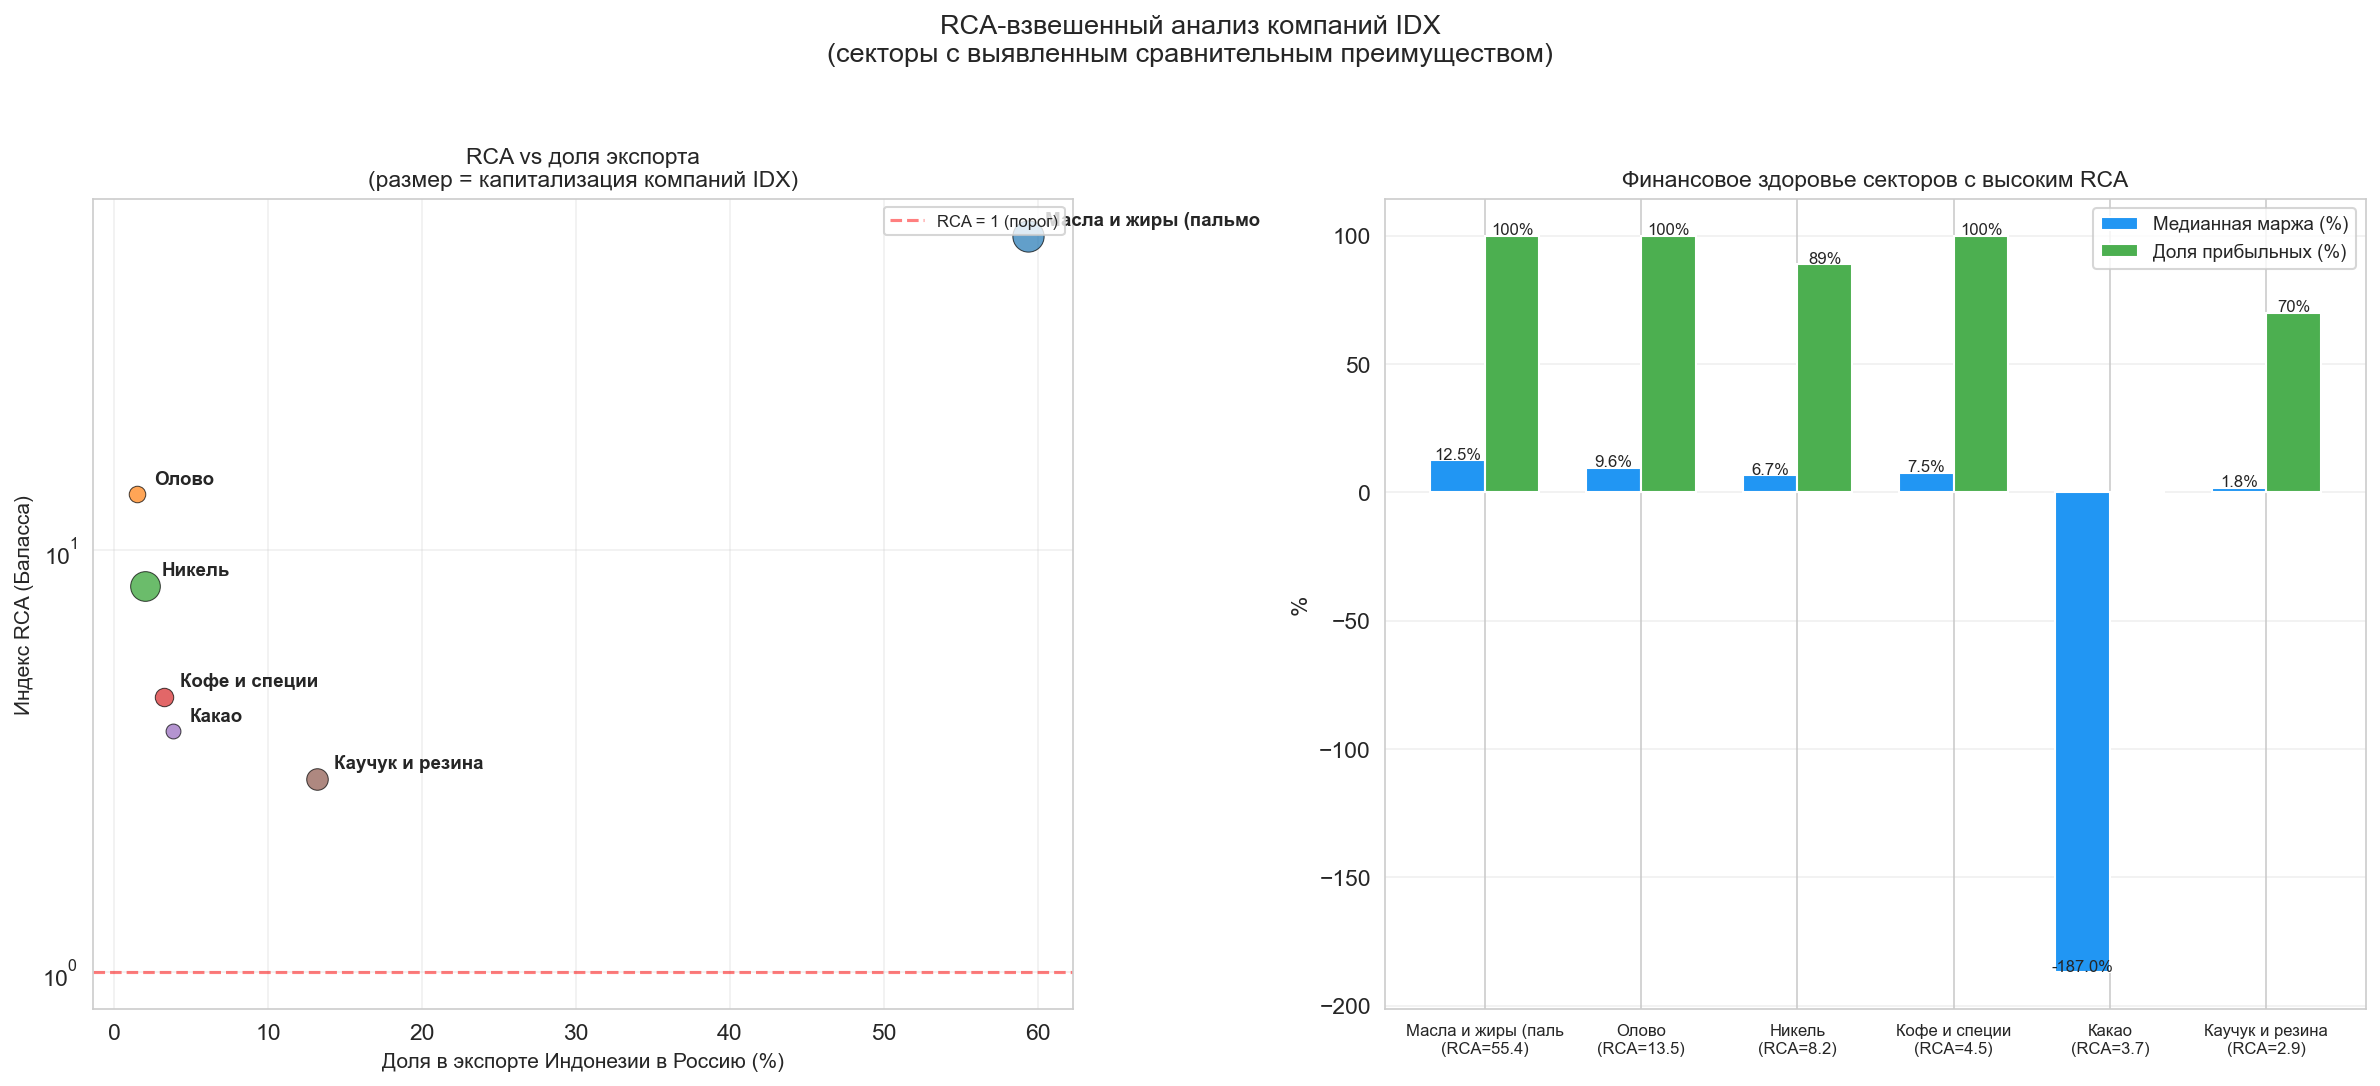

In [29]:
# --- RCA bubble chart + финансовый профиль ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Bubble chart: RCA x доля экспорта x капитализация
for _, row in rca_agg_df.iterrows():
    hs = row['HS-группа']
    name = hs.split(' — ')[1][:20] if ' — ' in hs else hs[:20]
    ax1.scatter(row['Доля в экспорте (%)'], row['RCA'],
                s=row['Капитализация ($B)'] * 8 + 50,
                alpha=0.7, edgecolors='black', linewidth=0.5, zorder=5)
    ax1.annotate(name,
                 (row['Доля в экспорте (%)'], row['RCA']),
                 textcoords='offset points', xytext=(8, 5),
                 fontsize=9, fontweight='bold')

ax1.set_xlabel('Доля в экспорте Индонезии в Россию (%)', fontsize=10)
ax1.set_ylabel('Индекс RCA (Баласса)', fontsize=10)
ax1.set_title('RCA vs доля экспорта\n(размер = капитализация компаний IDX)', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')
ax1.axhline(1, color='red', linestyle='--', alpha=0.5, label='RCA = 1 (порог)')
ax1.legend(fontsize=8)

# Финансовый профиль: маржа и доля прибыльных
bars_names = []
margins = []
profitable = []
for _, row in rca_agg_df.iterrows():
    hs = row['HS-группа']
    short = hs.split(' — ')[1][:18] if ' — ' in hs else hs[:18]
    bars_names.append(f'{short}\n(RCA={row["RCA"]:.1f})')
    margins.append(row['Мед. маржа (%)'] if pd.notna(row['Мед. маржа (%)']) else 0)
    profitable.append(row['Доля прибыльных (%)'] if pd.notna(row['Доля прибыльных (%)']) else 0)

x = np.arange(len(bars_names))
width = 0.35
b1 = ax2.bar(x - width/2, margins, width, label='Медианная маржа (%)', color='#2196F3', edgecolor='white')
b2 = ax2.bar(x + width/2, profitable, width, label='Доля прибыльных (%)', color='#4CAF50', edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels(bars_names, fontsize=8)
ax2.set_ylabel('%')
ax2.set_title('Финансовое здоровье секторов с высоким RCA', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

for bar in b1:
    if bar.get_height() != 0:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=8)
for bar in b2:
    if bar.get_height() != 0:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.0f}%', ha='center', fontsize=8)

plt.suptitle('RCA-взвешенный анализ компаний IDX\n(секторы с выявленным сравнительным преимуществом)',
             fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '17_rca_weighted_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

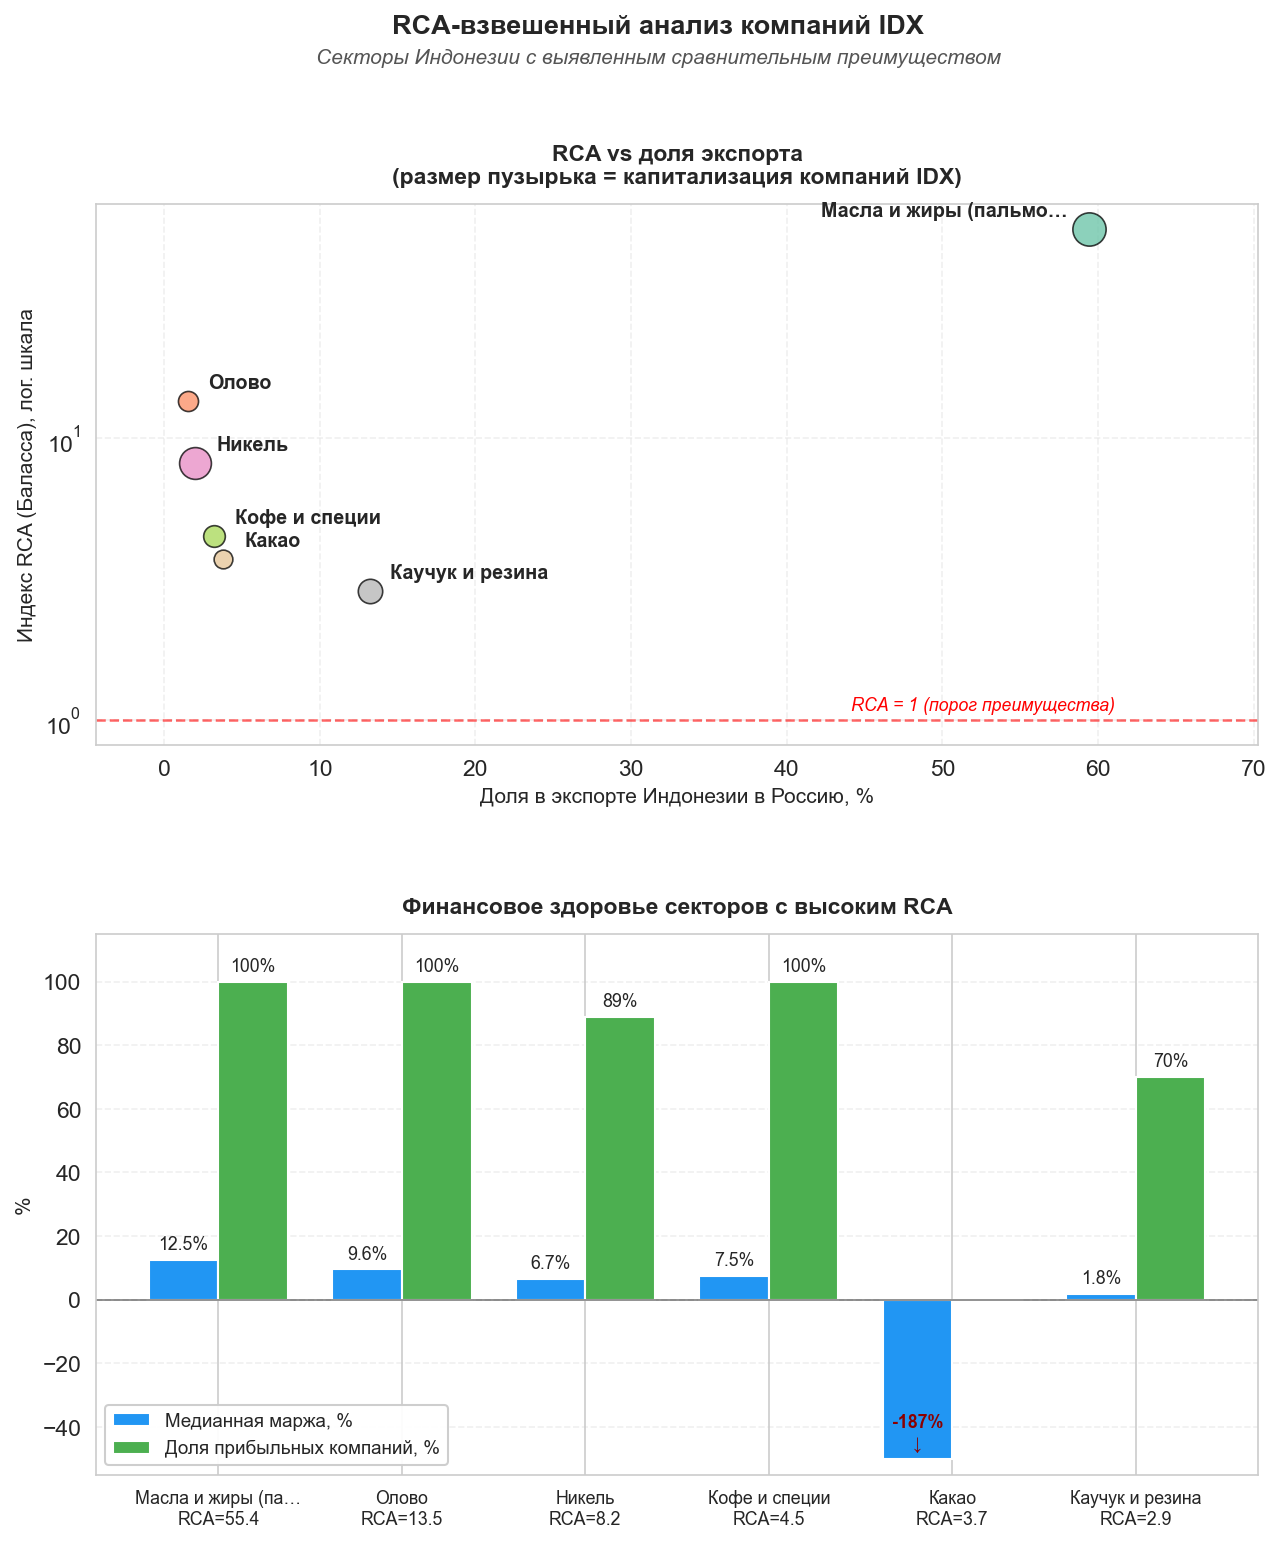

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Вертикальная компоновка: 2 строки, 1 колонка
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 11),
                                gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.35})

# ============ ВЕРХ: Bubble chart ============
# Цвета для каждого сектора — чтобы связать с нижним графиком
colors = plt.cm.Set2(np.linspace(0, 1, len(rca_agg_df)))
sector_colors = {}

for (idx, row), color in zip(rca_agg_df.iterrows(), colors):
    hs = row['HS-группа']
    name = hs.split(' — ')[1] if ' — ' in hs else hs
    # Сокращаем длинные названия аккуратно
    name_short = name if len(name) <= 22 else name[:20] + '…'
    sector_colors[hs] = color
    
    ax1.scatter(row['Доля в экспорте (%)'], row['RCA'],
                s=row['Капитализация ($B)'] * 8 + 80,
                alpha=0.75, edgecolors='black', linewidth=0.8,
                color=color, zorder=5)
    
    # Умное позиционирование подписей — сдвиг зависит от положения точки
    offset_x = 10 if row['Доля в экспорте (%)'] < 40 else -10
    ha = 'left' if offset_x > 0 else 'right'
    ax1.annotate(name_short,
                 (row['Доля в экспорте (%)'], row['RCA']),
                 textcoords='offset points', xytext=(offset_x, 6),
                 fontsize=9.5, fontweight='bold', ha=ha)

ax1.set_xlabel('Доля в экспорте Индонезии в Россию, %', fontsize=10)
ax1.set_ylabel('Индекс RCA (Баласса), лог. шкала', fontsize=10)
ax1.set_title('RCA vs доля экспорта\n(размер пузырька = капитализация компаний IDX)',
              fontsize=11, fontweight='bold', pad=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_yscale('log')
ax1.axhline(1, color='red', linestyle='--', alpha=0.6, linewidth=1.2)
ax1.text(ax1.get_xlim()[1] * 0.98, 1.05, 'RCA = 1 (порог преимущества)',
         ha='right', va='bottom', fontsize=8.5, color='red', style='italic')

# Даём больше места слева/справа для подписей
xlim = ax1.get_xlim()
ax1.set_xlim(xlim[0] - 3, xlim[1] + 8)

# ============ НИЗ: финансовый профиль ============
bars_names, margins, profitable, bar_colors = [], [], [], []
for _, row in rca_agg_df.iterrows():
    hs = row['HS-группа']
    short = hs.split(' — ')[1] if ' — ' in hs else hs
    short = short if len(short) <= 18 else short[:16] + '…'
    bars_names.append(short)
    margins.append(row['Мед. маржа (%)'] if pd.notna(row['Мед. маржа (%)']) else 0)
    profitable.append(row['Доля прибыльных (%)'] if pd.notna(row['Доля прибыльных (%)']) else 0)
    bar_colors.append(sector_colors[hs])

x = np.arange(len(bars_names))
width = 0.38

# КЛЮЧЕВОЕ: обрезаем ось на -50%, выброс -187% показываем отдельно
MARGIN_FLOOR = -50
margins_clipped = [max(m, MARGIN_FLOOR) for m in margins]
margins_outlier = [m < MARGIN_FLOOR for m in margins]

b1 = ax2.bar(x - width/2, margins_clipped, width,
             label='Медианная маржа, %', color='#2196F3',
             edgecolor='white', linewidth=1)
b2 = ax2.bar(x + width/2, profitable, width,
             label='Доля прибыльных компаний, %', color='#4CAF50',
             edgecolor='white', linewidth=1)

# Подписи для маржи
for bar, val, is_out in zip(b1, margins, margins_outlier):
    if is_out:
        # Выброс помечаем специально
        ax2.text(bar.get_x() + bar.get_width()/2, MARGIN_FLOOR + 2,
                 f'{val:.0f}%\n↓', ha='center', va='bottom',
                 fontsize=8.5, fontweight='bold', color='darkred')
    elif val != 0:
        offset = 2 if val >= 0 else -5
        va = 'bottom' if val >= 0 else 'top'
        ax2.text(bar.get_x() + bar.get_width()/2, val + offset,
                 f'{val:.1f}%', ha='center', va=va, fontsize=8.5)

# Подписи для доли прибыльных
for bar, val in zip(b2, profitable):
    if val != 0:
        ax2.text(bar.get_x() + bar.get_width()/2, val + 2,
                 f'{val:.0f}%', ha='center', va='bottom', fontsize=8.5)

# RCA как отдельная строка под названием сектора (мельче)
rca_labels = [f'{n}\nRCA={r:.1f}' for n, r in zip(bars_names, rca_agg_df['RCA'])]
ax2.set_xticks(x)
ax2.set_xticklabels(rca_labels, fontsize=8.5)
ax2.set_ylabel('%', fontsize=10)
ax2.set_title('Финансовое здоровье секторов с высоким RCA',
              fontsize=11, fontweight='bold', pad=10)
ax2.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax2.set_ylim(MARGIN_FLOOR - 5, 115)
ax2.legend(fontsize=9, loc='lower left', framealpha=0.95)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('RCA-взвешенный анализ компаний IDX',
             fontsize=13, fontweight='bold', y=0.995)
fig.text(0.5, 0.965, 'Секторы Индонезии с выявленным сравнительным преимуществом',
         ha='center', fontsize=10, style='italic', color='#555')

plt.savefig(os.path.join(OUT_DIR, '17_rca_weighted_analysis.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

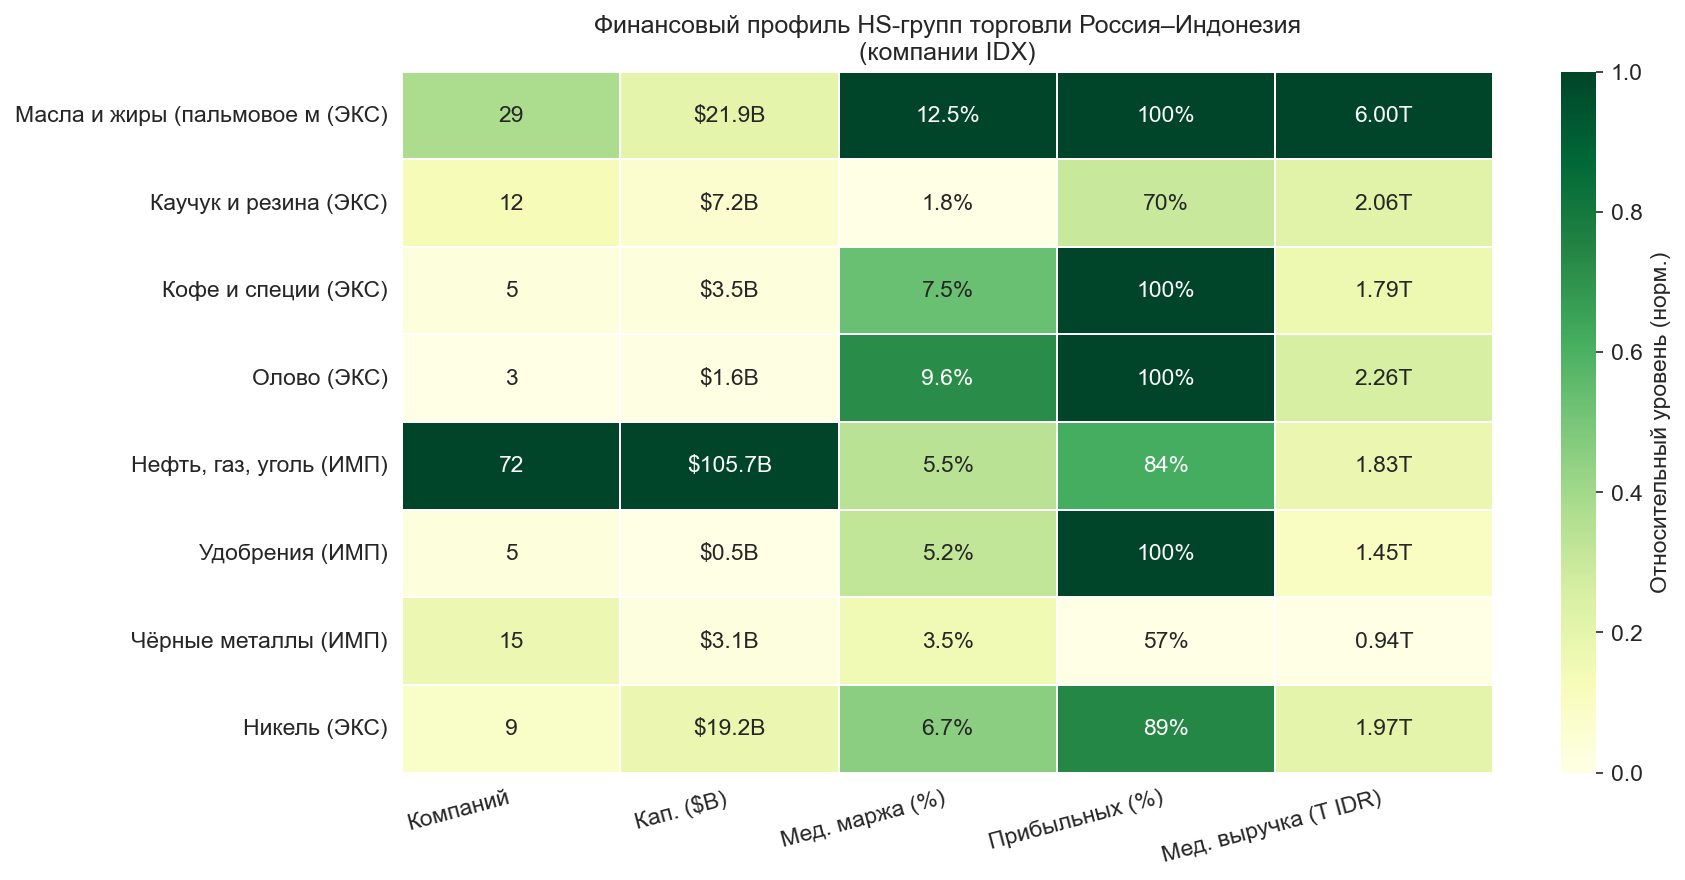


Итого: 152 совпадений по 9 HS-группам


In [31]:
# --- Сводная heatmap: HS-группы x финансовые показатели ---
heat_data = []
for hs_name, matched in hs_company_lists.items():
    if len(matched) == 0:
        continue
    has_fin = matched[matched['Revenue'] > 0]
    if len(has_fin) < 3:
        continue
    config = HS_COMPANY_MAP[hs_name]
    short = hs_name.split(' — ')[1][:25] if ' — ' in hs_name else hs_name[:25]
    direction = 'ЭКС' if 'share_export' in config else 'ИМП'
    heat_data.append({
        'Группа': f'{short} ({direction})',
        'Компаний': len(matched),
        'Кап. ($B)': matched['MCap_USD_B'].sum(),
        'Мед. маржа (%)': has_fin['Profit_Margin'].median(),
        'Прибыльных (%)': (has_fin['Net_Income'] > 0).mean() * 100,
        'Мед. выручка (T IDR)': has_fin['Revenue'].median() / 1e12,
    })

heat_df = pd.DataFrame(heat_data).set_index('Группа')
fig, ax = plt.subplots(figsize=(12, 6))

heat_norm = heat_df.copy()
for col in heat_norm.columns:
    vmin, vmax = heat_norm[col].min(), heat_norm[col].max()
    if vmax > vmin:
        heat_norm[col] = (heat_norm[col] - vmin) / (vmax - vmin)
    else:
        heat_norm[col] = 0.5

annot = heat_df.copy()
annot['Компаний'] = annot['Компаний'].apply(lambda x: f'{x:.0f}')
annot['Кап. ($B)'] = annot['Кап. ($B)'].apply(lambda x: f'${x:.1f}B')
annot['Мед. маржа (%)'] = annot['Мед. маржа (%)'].apply(lambda x: f'{x:.1f}%')
annot['Прибыльных (%)'] = annot['Прибыльных (%)'].apply(lambda x: f'{x:.0f}%')
annot['Мед. выручка (T IDR)'] = annot['Мед. выручка (T IDR)'].apply(lambda x: f'{x:.2f}T')

sns.heatmap(heat_norm, annot=annot.values, fmt='', cmap='YlGn', ax=ax,
            linewidths=0.8, cbar_kws={'label': 'Относительный уровень (норм.)'})
ax.set_title('Финансовый профиль HS-групп торговли Россия–Индонезия\n(компании IDX)', fontsize=12)
ax.set_ylabel('')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '18_hs_financial_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nИтого: {sum(len(v) for v in hs_company_lists.values())} совпадений по {len(hs_company_lists)} HS-группам')

In [32]:
# --- Экспорт результатов ---
# Сохраняем кластеризованный датасет
df_clust.to_csv(os.path.join(OUT_DIR, '..', 'asean_clustered.csv'), index=False, encoding='utf-8-sig')
print('Сохранено: Company_analysis/asean_clustered.csv')

# IDX с финансовыми данными
df_idx_c.to_csv(os.path.join(OUT_DIR, '..', 'idx_clustered_financial.csv'), index=False, encoding='utf-8-sig')
print('Сохранено: Company_analysis/idx_clustered_financial.csv')

print(f'\nВсего графиков: {len(os.listdir(OUT_DIR))}')
for f in sorted(os.listdir(OUT_DIR)):
    print(f'  {f}')

Сохранено: Company_analysis/asean_clustered.csv
Сохранено: Company_analysis/idx_clustered_financial.csv

Всего графиков: 36
  01_exchanges_overview.png
  02_mcap_distribution.png
  03_sector_structure.png
  04_hhi_concentration.png
  05_elbow_silhouette.png
  06_pca_clusters.png
  07_trade_sectors.png
  08_cosine_radar.png
  09_idx_clusters_pca.png
  10_idx_sectors_margins.png
  11_malaysia_pe_div.png
  12_sgx_jurisdictions.png
  13_vietnam_tiers.png
  14_top20_companies.png
  15_heatmap_sectors.png
  16_hs_company_mapping.png
  17_rca_weighted_analysis.png
  18_hs_financial_heatmap.png
  clust_01_isic_by_country.png
  clust_02_distributions.png
  clust_03_boxcox_vs_yeojohnson.png
  clust_04_scalers_comparison.png
  clust_05_pca_overview.png
  clust_06_optimal_k.png
  clust_07_gap_bic.png
  clust_08_kmeans_pca.png
  clust_09_kmeans_profiles.png
  clust_10_dendrogram.png
  clust_11_hierarchical_pca.png
  clust_12_kdistance.png
  clust_13_dbscan_pca.png
  clust_14_gmm_pca.png
  clust_15_

---
## Выводы

### Масштаб и структура рынков АСЕАН
Пять крупнейших фондовых бирж АСЕАН насчитывают **5 245 публичных компаний** с совокупной капитализацией **~$2 652 млрд**. SGX (Сингапур) лидирует по капитализации ($670 млрд), а Вьетнам — по числу эмитентов (1 547). Медианная капитализация невелика (<$50 млн), что говорит о преобладании МСП.

### Секторальная структура
- **Обрабатывающая промышленность (C)** — лидер по числу компаний (2 249, 43%), особенно во Вьетнаме (60%) и Малайзии (50%).
- **Финансовый сектор (K)** — лидер по капитализации ($790 млрд, 30%), благодаря банкам-гигантам (DBS $121B, BCA $52B).
- HHI варьируется от 1 154 (SET — диверсифицированный) до 3 876 (Вьетнам — высокая концентрация).

### Комплементарность с Россией
- Косинусная близость: **Индонезия (0.84)** > Вьетнам (0.81) > Малайзия (0.77) > Сингапур (0.71) > Таиланд (0.67).
- **3 520 компаний** ($1 805 млрд) в секторах, непосредственно связанных с российско-асеановской торговлей.

### Кластерный анализ
- **АСЕАН-wide**: K-Means (K=6) выделяет группы по ISIC-профилю и размеру.
- **IDX (детальный)**: K=4 кластера по 5 финансовым показателям (Silhouette ≈ 0.60). Структурный разрыв: финансовый сектор (маржа 15.7%) vs промышленность (3.3%).

### Страновые особенности
- **Индонезия**: наибольшая комплементарность с Россией; Energy/Materials — потенциал технологического сотрудничества.
- **Малайзия**: наиболее диверсифицированная биржа; электроника, пальмовое масло. Медианный P/E умеренный.
- **Таиланд**: равномерная секторальная структура; крупнейший строительный сектор в регионе.
- **Вьетнам**: UPCOM (842 комп.) расширяет доступ к МСП; высокая концентрация в обработке.
- **Сингапур**: финансовый хаб; 7.1% компаний в офшорах (санкционные риски).